# Classification Model

## Set Up

In [1]:
import os
import sys

current_dir = os.getcwd()
new_root = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm'
sys.path.insert(0, new_root)

In [2]:
import configuration
import pandas as pd
import openpyxl
import random
import numpy as np
from itertools import product
import seaborn as sns

from src.data.load_data import * #load_configuration_parameters, load_file
from src.data.preprocess import *
from src.base.localizator import * #get_candidates
from src.features.build_features import *
from src.features.build_features_utils import *
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold, StratifiedShuffleSplit, GroupKFold, StratifiedGroupKFold
from sklearn import svm
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_validate
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.metrics import make_scorer, recall_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

In [3]:
# Optional: XGBoost if available
def _get_xgb():
    try:
        from xgboost import XGBClassifier
        return XGBClassifier
    except Exception:
        return None

XGBClassifier = _get_xgb()

In [4]:
mode = 'model-training'
subjects = configuration.SUBJECTS
window = 2 #in seconds
fs = 200 #To check!

Experts analysis:

In [ ]:
# subject = subjects[0]
# eeg_channel, path_file, scoring_path, _, cut_off_freqs = load_configuration_parameters(subject, subject, mode)
# df_data = pd.read_excel(r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\annotations\Resume_Annotations_2025.xlsx", sheet_name=subject[3:])[['onset', 'duration','Label','CG','LG']]
# flags=np.zeros(df_data.shape[0]) 

# df_KC = df_data[df_data.Label == 'KC']
# KC_idx = list(df_KC.index)

# df_noKC = df_data[df_data.Label == 'noKC']

# df_noKC_labeled = df_data[(df_data.CG == 0) & (df_data.LG == 0)]

# noKC_idx_candidates = [idx for idx in df_noKC.index if idx not in df_noKC_labeled.index]
# L = df_KC.shape[0]-df_noKC_labeled.shape[0]

# if L > 0:
#     noKC_idx = list(df_noKC_labeled.index) + random.sample(noKC_idx_candidates, L)
# else:
#     noKC_idx = random.sample(list(df_noKC_labeled.index), len(KC_idx))

# assert len(noKC_idx) == len(set(noKC_idx)) #QC
# flags[noKC_idx] = 1
# flags[KC_idx] = 1

# df_data["Flags"] = flags

In [ ]:
def get_KC_event(onset_duration, signal, sfreq, window=2, timelocked2='center', return_start_of_event=False):
    """
    Get KC event
    """
    onset, duration = onset_duration
    if timelocked2 == 'center':
        start = int(onset*sfreq)
        end = int(start + duration*sfreq)
        KC_labeled = signal[start:end]
        center, maxi, mini = get_center_maxi_mini(KC_labeled)
        center_in_signal = int(start + center)
        mini_to_center = abs(mini-center)
        maxi_to_center = abs(maxi-center)
        new_start = center_in_signal-int(window*sfreq/2)
        KC = signal[new_start:center_in_signal+int(window*sfreq/2)]
    elif timelocked2 == 'min':
        start = int(onset*sfreq)
        end = int(start + duration*sfreq)
        KC_labeled = signal[start:end]
        center, maxi, mini = get_center_maxi_mini(KC_labeled)
        center_in_signal = start + mini
        mini_to_center = 0
        maxi_to_center = abs(maxi-mini)
        new_start = center_in_signal-int(window*sfreq/2)
        #KC = signal[new_start:center_in_signal-int(window*sfreq/2)]
        KC = signal[new_start:new_start+int(window*sfreq)]

    if return_start_of_event:
        return new_start
    else:
        return KC, maxi_to_center, mini_to_center

## Selecting events to train model

In [ ]:
subject = subjects[0]
pd.read_excel(r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\annotations\Resume_Annotations_2025.xlsx", sheet_name=subject[3:])[['onset', 'duration','Label','CG','LG']]

In [ ]:
df_overall_agreement = pd.DataFrame(data=[], columns=["Agreement", "CG", "LG"])
for subject in subjects:
    print(subject)
    df_data = pd.read_excel(r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\annotations\Resume_Annotations_2025.xlsx", sheet_name=subject[3:])[['Label','CG','LG']]
    df_data['Agreement'] = np.where((df_data['CG'] == df_data['LG']), 1, 0)    
    df_overall_agreement = pd.concat([df_overall_agreement, df_data],  ignore_index=True)

In [ ]:
df_overall_agreement.to_csv('overall_results_timelocked2min_AGREEMENT.csv')

In [ ]:
# df_overall = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label", "Flag"])

# for subject in subjects:
#     eeg_channel, path_file, scoring_path, _, cut_off_freqs = load_configuration_parameters(subject, subject, mode)
#     df_data = pd.read_excel(r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\annotations\Resume_Annotations_2025.xlsx", sheet_name=subject[3:])[['onset', 'duration','Label','CG','LG']]
#     flags=np.zeros(df_data.shape[0]) 

#     df_KC = df_data[df_data.Label == 'KC']
#     KC_idx = list(df_KC.index)

#     df_noKC = df_data[df_data.Label == 'noKC']

#     df_noKC_labeled = df_data[(df_data.CG == 0) & (df_data.LG == 0)]
#     df_KC_agreement = np.where((df_data['CG'] == df_data['LG']), 1, 0)
#     df_KC_CG = np.where(df_data['CG'] == 1, 1, 0)
#     df_KC_LG = np.where(df_data['LG'] == 1, 1, 0)

#     noKC_idx_candidates = [idx for idx in df_noKC.index if idx not in df_noKC_labeled.index]
#     L = df_KC.shape[0]-df_noKC_labeled.shape[0]
  
#     if L > 0:
#         noKC_idx = list(df_noKC_labeled.index) + random.sample(noKC_idx_candidates, L)
#     else:
#         noKC_idx = random.sample(list(df_noKC_labeled.index), len(KC_idx))

#     assert len(noKC_idx) == len(set(noKC_idx)) #QC
#     flags[noKC_idx] = 1
#     flags[KC_idx] = 1

#     df_data["Flags"] = flags
#     df_data["Agreement"] = df_KC_agreement
#     df_data["CG"] = df_KC_CG
#     df_data["LG"] = df_KC_LG

#     #Load file
#     raw, channels = load_file(path_file)
#     fs = raw.info['sfreq']

#     #Filter each channel depending on type
#     raw_filtered = filter_raw_depending_on_channel_type(raw, channels, cut_off_freqs)

#     #Structure data depending on channel type
#     raw_restructured, _ = structure_data_depending_on_channel_type(raw_filtered, channels, eeg_channels_selected=[eeg_channel])

#     #Load and set labels (scoring and old annotations)
#     raw_with_sleep_stages = set_sleep_stages_labels(raw_restructured, scoring_path)

#     # Get eeg signal
#     eeg_signal = raw_with_sleep_stages.get_data(picks=[eeg_channel])[0]
#     eeg_signal = eeg_signal * 1e6

#     #Set annotations
#     KC_noKC_annots = mne.Annotations(onset=df_data.onset, duration=df_data.duration, description=df_data.Label)
#     raw_wih_all_annotations = raw_with_sleep_stages.copy().set_annotations(KC_noKC_annots)

#     #List of events
#     df_events = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label", "Flag", "Agreement", "CG", "LG"])

#     for values in df_data.values:
#         annot = {'onset': values[0], 'duration': values[1], 'description': values[2]}
#         if annot['description'] == "KC":
#             KC, _, _ = get_KC_event((annot['onset'], annot['duration']), eeg_signal, sfreq=fs, window=window, timelocked2='center', return_start_of_event=False)
#             df_events.loc[len(df_events)] = [float(i) for i in KC] + [subject, 'KC', values[-4], values[-3] , values[-2], values[-1]]
            
#         elif annot['description'] == 'noKC':
#             noKC, _, _ = get_KC_event((annot['onset'], annot['duration']), eeg_signal, sfreq=fs, window=window, timelocked2='center', return_start_of_event=False)
#             df_events.loc[len(df_events)] = [float(i) for i in noKC] + [subject, 'noKC', values[-4], values[-3] , values[-2], values[-1]]
#     df_overall = pd.concat([df_overall, df_events],  ignore_index=True)

In [5]:
df_overall_agreement = pd.read_csv('overall_results_timelocked2min_AGREEMENT.csv').drop(columns='Unnamed: 0')
df_overall_agreement.head()

,Agreement,CG,LG,Label
0,0,0.0,1.0,KC
1,0,NaN,NaN,noKC
2,1,1.0,1.0,KC
3,0,NaN,NaN,noKC
4,1,1.0,1.0,KC


In [6]:
df_overall = pd.read_csv('overall_results_labeled_events_timelocked2min.csv').drop(columns='Unnamed: 0')
df_overall.head()

,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9,sample10,...,sample394,sample395,sample396,sample397,sample398,sample399,sample400,Subject,Label,Flag
0,11.065373,10.976487,11.084059,11.118682,11.447237,12.760064,15.035535,17.093893,17.516870,16.089690,...,-8.125721,-8.815218,-9.638562,-10.156404,-10.176293,-9.632467,-8.478279,ExpS11,KC,1.0
1,-15.766161,-21.388573,-27.509857,-32.180180,-33.585653,-31.399859,-26.916821,-21.922944,-17.533469,-14.078776,...,2.353905,0.615360,-1.475125,-2.756062,-2.641661,-1.472889,-0.033071,ExpS11,noKC,0.0
2,-19.544320,-13.724322,-10.165823,-8.456079,-7.873763,-7.961593,-8.543847,-9.316248,-9.569967,-8.415983,...,-1.165422,-2.292436,-3.308349,-3.900886,-4.034183,-3.976365,-4.065779,ExpS11,KC,1.0
3,13.385444,15.824357,15.901995,13.763481,10.504548,7.480328,5.607487,5.110638,5.690225,6.810159,...,-4.196666,-2.912441,-2.155152,-1.637799,-1.162614,-0.562837,0.271435,ExpS11,noKC,0.0
4,-3.918705,0.460572,5.237947,10.332355,15.309483,19.837669,23.998722,28.039930,31.828016,34.648777,...,-15.826182,-13.840772,-11.078033,-8.679499,-7.329848,-6.809974,-6.236012,ExpS11,KC,1.0


In [7]:
df_overall_agreement.shape, df_overall.shape

((3571, 4), (3571, 403))

In [8]:
df_overall['Agreement'] = df_overall_agreement['Agreement']
df_overall['CG'] = df_overall_agreement['CG']
df_overall['LG'] = df_overall_agreement['LG']

df_overall

,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9,sample10,...,sample397,sample398,sample399,sample400,Subject,Label,Flag,Agreement,CG,LG
0,11.065373,10.976487,11.084059,11.118682,11.447237,12.760064,15.035535,17.093893,17.516870,16.089690,...,-10.156404,-10.176293,-9.632467,-8.478279,ExpS11,KC,1.0,0,0.0,1.0
1,-15.766161,-21.388573,-27.509857,-32.180180,-33.585653,-31.399859,-26.916821,-21.922944,-17.533469,-14.078776,...,-2.756062,-2.641661,-1.472889,-0.033071,ExpS11,noKC,0.0,0,NaN,NaN
2,-19.544320,-13.724322,-10.165823,-8.456079,-7.873763,-7.961593,-8.543847,-9.316248,-9.569967,-8.415983,...,-3.900886,-4.034183,-3.976365,-4.065779,ExpS11,KC,1.0,1,1.0,1.0
3,13.385444,15.824357,15.901995,13.763481,10.504548,7.480328,5.607487,5.110638,5.690225,6.810159,...,-1.637799,-1.162614,-0.562837,0.271435,ExpS11,noKC,0.0,0,NaN,NaN
4,-3.918705,0.460572,5.237947,10.332355,15.309483,19.837669,23.998722,28.039930,31.828016,34.648777,...,-8.679499,-7.329848,-6.809974,-6.236012,ExpS11,KC,1.0,1,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3566,16.262100,18.582830,19.724396,19.705214,18.598212,16.798921,14.894294,12.974785,10.204442,5.465782,...,-2.706535,-1.269455,2.022668,6.550265,ExpS66,noKC,0.0,0,NaN,NaN
3567,11.682353,12.178262,11.888932,10.948162,9.504171,7.627311,5.353703,2.859302,0.623325,-0.653751,...,-3.975144,-7.266839,-12.330091,-18.403873,ExpS66,noKC,0.0,0,NaN,NaN
3568,3.481708,5.382661,8.211052,10.705648,11.907266,11.661121,10.515482,9.274622,8.548887,8.485050,...,4.635788,3.463757,2.199010,0.263231,ExpS66,noKC,0.0,0,NaN,NaN
3569,18.894795,16.257339,14.358439,14.370105,16.505668,19.427122,21.164793,20.837846,19.504294,19.265501,...,-8.707946,-7.190511,-4.341550,-0.056660,ExpS66,noKC,0.0,0,NaN,NaN


In [9]:
# Fill CG and LG with -1 where they are NaN
df_overall = df_overall.fillna(-1)

In [ ]:
# df_overall = pd.read_csv('overall_results_labeled_events_timelocked2min.csv').drop(columns='Unnamed: 0')
#df_overall = pd.read_csv('overall_results_labeled_events_timelocked2center.csv').drop(columns='Unnamed: 0')

In [10]:
df_overall[['Label','Flag']].value_counts()

Label  Flag
noKC   0.0     3091
KC     1.0      240
noKC   1.0      240
Name: count, dtype: int64

In [ ]:
df_overall.columns

In [11]:
#Overall: N=3331 noKC & N=240 KC
y_overall = df_overall.copy()['Label']
X_overall = df_overall.drop(columns=['Label','Subject', 'Flag', 'Agreement', 'CG', 'LG'])

#Model: N=240 noKC & N=240 KC
df_model = df_overall[df_overall.Flag==1].reset_index().drop(columns=['index'])
y_model = df_model.copy()['Label']
X_model = df_model.drop(columns=['Label','Subject', 'Flag', 'Agreement', 'CG', 'LG'])

In [12]:
X_overall.shape, X_model.shape

((3571, 400), (480, 400))

In [159]:
df_overall.to_csv('overall_results_timelocked2min_COMPLETE.csv')

### Visual analysis of dataset

In [ ]:
t = np.linspace(0,2,2*200)
plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'KC')], axis=0).values, label=f"KC (N={len(X_overall.iloc[np.where(y_overall == 'KC')])})", color = 'goldenrod')
plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'noKC')], axis=0).values, label=f"noKC (N={len(X_overall.iloc[np.where(y_overall == 'noKC')])})", color = 'mediumblue')
plt.legend()
plt.title(f'KCs labeled vs no-KCs')
plt.ylim(-120,120)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [μV]')
#plt.savefig(rf'KC_vs_noKC_LSYM_timelocked2center.png')
plt.show()

In [ ]:
# For imbalance of dataset, "Flag" column was created to detect same number of noKC that can train a model
df_overall[['Label','Flag']].value_counts()

In [ ]:
sample_columns = [col for col in df_overall.columns if col not in ['Subject', 'Label', 'Flag']]
KC_overall = df_overall[df_overall['Label']=='KC'][sample_columns]
noKC_overall = df_overall[(df_overall['Label']=='noKC') & df_overall['Flag']==1][sample_columns]


In [ ]:
t = np.linspace(0,2,2*200)
for KC in KC_overall.values:
    plt.plot(t, KC, color = 'goldenrod', linewidth=0.1, alpha=0.5)
plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'KC')], axis=0).values, linewidth = 2, color = 'black')
plt.title(f'KCs')
plt.ylim(-120,120)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [μV]')
plt.show()

In [ ]:
t = np.linspace(0,2,2*200)
for noKC in noKC_overall.values:
    plt.plot(t, noKC, color = 'mediumblue', linewidth=0.1, alpha=0.5)
plt.plot(t, np.mean(X_overall.iloc[np.where(y_overall == 'noKC')], axis=0).values, linewidth = 2, color = 'black')
plt.title(f'Non-KCs (N={len(noKC_overall)})')
plt.ylim(-120,120)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [μV]')
plt.show()

## Samples

In [ ]:
# path = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\reports\models\NuSVM_bestmodel_2025-06-10.joblib'
# model = joblib.load(path)
# model.predict(sc.transform(sig.values.reshape(-1, 1)).reshape(1, -1))

In [ ]:
scaler = StandardScaler()
scaler.fit(X_model.values.T)
X_model_scaled = scaler.transform(X_model.values.T) #Scaled in rows
X_model_scaled = pd.DataFrame(data=X_model_scaled.T, columns=X_model.columns)

scaler = StandardScaler()
scaler.fit(X_overall.values.T)
X_overall_scaled = scaler.transform(X_overall.values.T) #Scaled in rows
X_overall_scaled = pd.DataFrame(data=X_overall_scaled.T, columns=X_overall.columns)


scaler2 = MinMaxScaler()
scaler2.fit(X_model.values.T)
X_model_scaled2 = scaler2.transform(X_model.values.T) #Scaled in rows
X_model_scaled2 = pd.DataFrame(data=X_model_scaled2.T, columns=X_model.columns)

scaler2 = MinMaxScaler()
scaler2.fit(X_overall.values.T)
X_overall_scaled2 = scaler2.transform(X_overall.values.T) #Scaled in rows
X_overall_scaled2 = pd.DataFrame(data=X_overall_scaled2.T, columns=X_overall.columns)

In [ ]:
X_model_train, X_model_test, y_model_train, y_model_test = train_test_split(X_model, y_model, test_size=0.2, random_state=10)

X_overall_train, X_overall_test, y_overall_train, y_overall_test = train_test_split(X_overall, y_overall, test_size=0.2, random_state=10)

X_model_scaled_train, X_model_scaled_test, y_model_scaled_train, y_model_scaled_test = train_test_split(X_model_scaled, y_model, test_size=0.2, random_state=10)

X_overall_scaled_train, X_overall_scaled_test, y_overall_scaled_train, y_overall_scaled_test = train_test_split(X_overall_scaled, y_overall, test_size=0.2, random_state=10)

X_overall_scaled2_train, X_overall_scaled2_test, y_overall_scaled2_train, y_overall_scaled2_test = train_test_split(X_overall_scaled2, y_overall, test_size=0.2, random_state=10)


### Figures

In [ ]:
t = np.linspace(0,2,2*200)
plt.plot(t, np.mean(X_overall_scaled.iloc[np.where(y_overall == 'KC')], axis=0).values, label=f"KC (N={len(X_overall_scaled.iloc[np.where(y_overall == 'KC')])})", color = 'goldenrod')
plt.plot(t, np.mean(X_overall_scaled.iloc[np.where(y_overall == 'noKC')], axis=0).values, label=f"noKC (N={len(X_overall_scaled.iloc[np.where(y_overall == 'noKC')])})", color = 'mediumblue')
plt.legend()
plt.title('Mean of KC vs mean noKC - Scaled samples')
plt.show()

In [ ]:
t = np.linspace(0,2,2*200)
plt.plot(t, np.mean(X_model_scaled.iloc[np.where(y_model == 'KC')], axis=0).values, label=f'KC (N={len(X_model_scaled.iloc[np.where(y_model == "KC")])})', color = 'goldenrod')
plt.plot(t, np.mean(X_model_scaled.iloc[np.where(y_model == 'noKC')], axis=0).values, label=f'noKC (N={len(X_model_scaled.iloc[np.where(y_model == "noKC")])})', color = 'mediumblue')
plt.legend()
plt.title('Mean of KC vs mean noKC - Balanced std and scaled samples')
plt.show()

In [ ]:
t = np.linspace(0,2,2*200)
plt.plot(t, np.mean(X_model_scaled2.iloc[np.where(y_model == 'KC')], axis=0).values, label=f'KC (N={len(X_model_scaled.iloc[np.where(y_model == "KC")])})', color = 'goldenrod')
plt.plot(t, np.mean(X_model_scaled2.iloc[np.where(y_model == 'noKC')], axis=0).values, label=f'noKC (N={len(X_model_scaled.iloc[np.where(y_model == "noKC")])})', color = 'mediumblue')
plt.legend()
plt.title('Mean of KC vs mean noKC - Balanced min-max and scaled samples')
plt.show()

## Models

In [ ]:
def kc_metrics(y_true, y_pred, positive_label="KC", fn_cost=10.0, fp_cost=1.0, beta=5.0):
    """
    KC-aware performance metrics with heavy penalty on False Negatives (missed KCs).
    
    Assumptions:
      - positive_label corresponds to KC ("True" class in your language)
      - negative_label corresponds to noKC ("False" class)
    
    Parameters
    ----------
    y_true, y_pred : array-like
        True and predicted labels. Can be strings ("KC"/"noKC") or booleans.
    positive_label : str|bool|int
        The label value representing KC in y_true/y_pred.
    fn_cost : float
        Cost weight for FN (KC predicted as noKC). Set high (e.g., 10-50).
    fp_cost : float
        Cost weight for FP (noKC predicted as KC). Usually lower (e.g., 1).
    beta : float
        F-beta score parameter (>1 emphasizes recall, i.e., punishes FN more).
    
    Returns
    -------
    dict with TP, TN, FP, FN and derived metrics + custom cost.
 
    >> Returns confusion counts + recall/precision/Fbeta + FN-averse cost + utility (higher is better).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    labels = np.unique(np.concatenate([y_true, y_pred]))
    if positive_label not in labels:
        raise ValueError(f"positive_label={positive_label} not found in labels={labels.tolist()}")

    neg_labels = [l for l in labels if l != positive_label]
    if len(neg_labels) != 1:
        raise ValueError(f"Expected exactly 1 negative label besides {positive_label}, got {neg_labels}")

    negative_label = neg_labels[0]

    cm = confusion_matrix(y_true, y_pred, labels=[negative_label, positive_label])
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    specificity = TN / (TN + FP) if (TN + FP) else 0.0

    beta2 = beta ** 2
    fbeta = (1 + beta2) * (precision * recall) / (beta2 * precision + recall) if (precision + recall) else 0.0

    weighted_cost = fn_cost * FN + fp_cost * FP
    n_pos = TP + FN
    n_neg = TN + FP
    max_cost = fn_cost * n_pos + fp_cost * n_neg
    normalized_cost = weighted_cost / max_cost if max_cost else 0.0
    utility = 1.0 - normalized_cost

    return {
        "TP": int(TP), "TN": int(TN), "FP": int(FP), "FN": int(FN),
        "precision(KC)": precision,
        "recall(KC)": recall,
        "specificity(noKC)": specificity,
        f"Fbeta(beta={beta})": fbeta,
        "weighted_cost": float(weighted_cost),
        "utility": float(utility),
    }

In [ ]:
# Helpers
def encode_binary_labels(y, positive_label="KC"):
    """
    Map labels to {0,1} for XGBoost.
    Returns y_bin (np.ndarray) and (neg_label, pos_label).
    """
    y = np.asarray(y)
    labels = np.unique(y)
    if positive_label not in labels:
        raise ValueError(f"positive_label={positive_label} not found in {labels.tolist()}")
    neg_labels = [l for l in labels if l != positive_label]
    if len(neg_labels) != 1:
        raise ValueError(f"Need binary labels; got {labels.tolist()}")
    neg_label = neg_labels[0]
    y_bin = (y == positive_label).astype(int)  # KC -> 1, noKC -> 0
    return y_bin, neg_label, positive_label

def decode_binary_preds(y_pred_bin, neg_label, pos_label):
    y_pred_bin = np.asarray(y_pred_bin).astype(int)
    return np.where(y_pred_bin == 1, pos_label, neg_label)

def safe_nu_for_fold(y_tr, positive_label="KC", nu_target=0.35, eps=1e-3):
    """
    Return a nu value that is feasible given class counts in this fold.
    A conservative bound is nu <= 2*min(n_pos, n_neg)/n_total.
    """
    y_tr = np.asarray(y_tr)
    n_total = len(y_tr)
    n_pos = int(np.sum(y_tr == positive_label))
    n_neg = n_total - n_pos
    if n_pos == 0 or n_neg == 0:
        # Can't train NuSVC in a single-class fold
        return None

    nu_max = 2.0 * min(n_pos, n_neg) / n_total  # conservative, commonly works well
    nu = min(nu_target, max(eps, nu_max - eps))
    return float(nu)

def fit_predict_with_safe_nusvc(model, X_tr, y_tr, X_te, positive_label="KC", nu_target=0.35):
    """
    Clone the NuSVC model, adapt nu to the fold, fit, and predict.
    If nu is still infeasible, back off nu until it works.
    """
    nu = safe_nu_for_fold(y_tr, positive_label=positive_label, nu_target=nu_target)
    if nu is None:
        raise ValueError("NuSVC cannot be trained: only one class present in this fold.")

    clf = clone(model)
    clf.set_params(nu=nu)

    # Retry loop: if still infeasible (rare), reduce nu progressively
    for _ in range(12):
        try:
            clf.fit(X_tr, y_tr)
            return clf.predict(X_te), clf.get_params()["nu"]
        except ValueError as e:
            if "nu is infeasible" in str(e).lower():
                nu = max(1e-4, nu * 0.8)
                clf.set_params(nu=nu)
            else:
                raise
    raise ValueError("NuSVC: could not find a feasible nu after retries.")

def choose_best_threshold(y_true, scores, positive_label="KC", fn_cost=25.0, fp_cost=1.0):
    """
    Find threshold on scores that maximizes FN-averse utility on training set.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    # candidate thresholds: quantiles + unique values (bounded)
    cand = np.unique(np.quantile(scores, np.linspace(0.01, 0.99, 99)))
    best_t, best_u = cand[0], -np.inf

    # Determine negative label
    labels = np.unique(y_true)
    neg_labels = [l for l in labels if l != positive_label]
    if len(neg_labels) != 1:
        raise ValueError("Threshold selection expects binary labels.")
    negative_label = neg_labels[0]

    for t in cand:
        y_pred = np.where(scores >= t, positive_label, negative_label)
        u = kc_metrics(y_true, y_pred, positive_label=positive_label, fn_cost=fn_cost, fp_cost=fp_cost)["utility"]
        if u > best_u:
            best_u, best_t = u, t
    return float(best_t), float(best_u)

def fit_kmeans_and_predict(train_X, train_y, test_X, positive_label="KC", random_state=7):
    """
    Fit KMeans(k=2) on train_X, map clusters to labels using majority vote on train_y,
    then predict labels for test_X.
    """
    km = KMeans(n_clusters=2, n_init=20, random_state=random_state)
    km.fit(train_X)

    train_clusters = km.labels_
    # map cluster -> label by majority in training data
    mapping = {}
    for c in [0, 1]:
        idx = (train_clusters == c)
        if idx.sum() == 0:
            mapping[c] = positive_label
        else:
            majority = pd.Series(train_y[idx]).value_counts().idxmax()
            mapping[c] = majority

    test_clusters = km.predict(test_X)
    y_pred = np.array([mapping[c] for c in test_clusters])
    return y_pred

In [ ]:
def get_models(random_state=7):
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        ),
        # Practical "least-squares-ish" linear classifier
        "LS-like (RidgeClassifier)": RidgeClassifier(class_weight="balanced", random_state=random_state),

        # Linear baseline (better than LinearRegression for classification)
        "LogReg": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear"
        ),

        "SVM (linear)": LinearSVC(class_weight="balanced", random_state=random_state, dual="auto"),
        "SVM (poly)": SVC(kernel="poly", degree=3, C=1.0, class_weight="balanced"),
        "SVM (rbf)":  SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced"),

        "NuSVC (linear)": NuSVC(kernel="linear", nu=0.35, class_weight="balanced"),
        "NuSVC (poly)":   NuSVC(kernel="poly", degree=3, nu=0.35, class_weight="balanced"),
        "NuSVC (rbf)":    NuSVC(kernel="rbf", nu=0.35, gamma="scale", class_weight="balanced"),

        "NaiveBayes (Gaussian)": GaussianNB(),

        # We'll handle KMeans and LinearRegression separately (not sklearn classifiers)
        "KMeans (unsupervised)": None,
        "LinearRegression (thresholded)": None,
    }

    if XGBClassifier is not None:
        models["XGBoost"] = XGBClassifier(
            n_estimators=600,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=random_state,
            n_jobs=-1,
            eval_metric="logloss",
            # handles imbalance (approx); you can tune this
            scale_pos_weight=10.0
        )
    else:
        print("⚠️ xgboost is not installed; skipping XGBoost model.")

    return models

def evaluate_models_subjectwise(
    X, y, subjects,
    positive_label="KC",
    fn_cost=25.0, fp_cost=1.0, beta=5.0,
    n_splits=5,
    random_state=7
):
    """
    Subject-wise GroupKFold evaluation for multiple models.
    Returns: (summary_df, per_fold_df)
    """
    X = np.asarray(X)
    y = np.asarray(y)
    subjects = np.asarray(subjects)

    gkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)#(n_splits=n_splits)
    models = get_models(random_state=random_state)

    fold_rows = []

    for model_name, model in models.items():
        for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups=subjects), start=1):
            
            X_tr, X_te = X[tr], X[te]
            y_tr, y_te = y[tr], y[te]

            extra = {}
            print(model_name)
            if model_name == "KMeans (unsupervised)":
                y_pred = fit_kmeans_and_predict(
                    train_X=X_tr, train_y=y_tr,
                    test_X=X_te,
                    positive_label=positive_label,
                    random_state=random_state
                )

            elif model_name == "LinearRegression (thresholded)":
                reg = LinearRegression()
                y_tr_bin = (y_tr == positive_label).astype(float)
                reg.fit(X_tr, y_tr_bin)

                tr_scores = reg.predict(X_tr)
                te_scores = reg.predict(X_te)

                t_star, _ = choose_best_threshold(
                    y_true=y_tr,
                    scores=tr_scores,
                    positive_label=positive_label,
                    fn_cost=fn_cost,
                    fp_cost=fp_cost
                )

                labels_all = np.unique(y)  # full dataset labels
                neg_labels = [l for l in labels_all if l != positive_label]
                if len(neg_labels) != 1:
                    raise ValueError("Need binary labels (KC vs noKC).")
                neg = neg_labels[0]

                y_pred = np.where(te_scores >= t_star, positive_label, neg)
                extra = {"linreg_threshold": t_star}

            elif isinstance(model, NuSVC):
                y_pred, nu_used = fit_predict_with_safe_nusvc(
                    model=model,
                    X_tr=X_tr, y_tr=y_tr,
                    X_te=X_te,
                    positive_label=positive_label,
                    nu_target=model.get_params().get("nu", 0.35)
                )
                extra = {"nu_used": nu_used}

            elif model_name == "XGBoost":
                y_tr_bin, neg_label, pos_label = encode_binary_labels(y_tr, positive_label=positive_label)

                n_pos = int(y_tr_bin.sum())
                n_neg = int((y_tr_bin == 0).sum())
                spw = (n_neg / max(n_pos, 1))

                clf = clone(model)
                clf.set_params(scale_pos_weight=spw)
                clf.fit(X_tr, y_tr_bin)

                y_pred_bin = clf.predict(X_te)
                y_pred = decode_binary_preds(y_pred_bin, neg_label=neg_label, pos_label=pos_label)
                extra = {"scale_pos_weight": spw}

            else:
                # Normal sklearn estimator
                clf = clone(model)
                clf.fit(X_tr, y_tr)
                y_pred = clf.predict(X_te)

            m = kc_metrics(
                y_true=y_te,
                y_pred=y_pred,
                positive_label=positive_label,
                fn_cost=fn_cost,
                fp_cost=fp_cost,
                beta=beta
            )

            fold_rows.append({
                "model": model_name,
                "fold": fold_idx,
                "n_test": len(te),
                **extra,
                **m
            })

    per_fold_df = pd.DataFrame(fold_rows)

    summary_df = (
        per_fold_df
        .groupby("model", as_index=False)
        .agg({
            "utility": ["mean", "std"],
            "weighted_cost": ["mean", "std"],
            "recall(KC)": ["mean", "std"],
            "precision(KC)": ["mean", "std"],
            "FP": ["mean", "sum"],
            "FN": ["mean", "sum"],
            "TP": ["mean", "sum"],
            "TN": ["mean", "sum"],
        })
    )

    # flatten columns
    summary_df.columns = ["model"] + [f"{a}_{b}" for a, b in summary_df.columns[1:]]
    summary_df = summary_df.sort_values("utility_mean", ascending=False).reset_index(drop=True)

    return summary_df, per_fold_df


In [ ]:
summary_df_balanced, per_fold_df = evaluate_models_subjectwise(
    X=X_model_scaled.values,
    y=y_model.values,
    subjects=df_model["Subject"].values,
    positive_label="KC",   
    fn_cost=10.0,          # Crank this up if FN is really unacceptable to 50
    fp_cost=1.0,
    beta=5.0,              # To emphasize recall strongly
    n_splits=5,
    random_state=7
)

summary_df_balanced

In [ ]:
summary_df_balanced.to_csv('all_algorithms_summary.csv', index=False)

> **Best performance:** SVM (rbf and poly) and NuSVC (rbf and poly)


## Optimize hyperparameters (balanced samples)

In [ ]:
def optimize_svm_model(
    model_type,
    param_grid,
    X,
    y,
    subjects,
    positive_label="KC",
    fn_cost=10,
    fp_cost=1,
    beta=5,
    n_splits=5,
    random_state=7):
    
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    results = []
    
    for params in product(*param_grid.values()):
        param_dict = dict(zip(param_grid.keys(), params))
        
        fold_utilities = []
        
        for tr, te in cv.split(X, y, groups=subjects):
            X_tr, X_te = X[tr], X[te]
            y_tr, y_te = y[tr], y[te]
            
            if model_type == "SVC":
                clf = SVC(kernel=param_dict.get("kernel"),
                          C=param_dict.get("C"),
                          gamma=param_dict.get("gamma"),
                          degree=param_dict.get("degree", 3),
                          class_weight="balanced")
                
                clf.fit(X_tr, y_tr)
                y_pred = clf.predict(X_te)
            
            elif model_type == "NuSVC":
                nu = param_dict.get("nu")
                
                clf = NuSVC(kernel=param_dict.get("kernel"),
                            nu=nu,
                            gamma=param_dict.get("gamma"),
                            degree=param_dict.get("degree", 3),
                            class_weight="balanced")
                
                # Use safe fitting
                try:
                    clf.fit(X_tr, y_tr)
                    y_pred = clf.predict(X_te)
                except:
                    continue
            
            metrics = kc_metrics(y_te, y_pred,
                                 positive_label=positive_label,
                                 fn_cost=fn_cost,
                                 fp_cost=fp_cost,
                                 beta=beta)
            
            fold_utilities.append(metrics["utility"])
        
        if len(fold_utilities) == n_splits:
            results.append({
                **param_dict,
                "mean_utility": np.mean(fold_utilities),
                "std_utility": np.std(fold_utilities)
            })
    
    results_df = pd.DataFrame(results).sort_values("mean_utility", ascending=False)
    
    best_params = results_df.iloc[0].to_dict()
    
    return results_df, best_params

### SVM rbf

In [ ]:
param_grid_rbf = {
    "kernel": ["rbf"],
    "C": [0.1, 0.5, 1, 2, 5, 10, 20],
    "gamma": ["scale", 0.01, 0.005, 0.001]
}

results_rbf, best_rbf = optimize_svm_model(
    model_type="SVC",
    param_grid=param_grid_rbf,
    X=X_model_scaled.values,
    y=y_model.values,
    subjects=df_model["Subject"].values
)

In [ ]:
best_rbf

### SVM poly

In [ ]:
param_grid_poly = {
    "kernel": ["poly"],
    "C": [0.1, 1, 5, 10],
    "degree": [2, 3, 4],
    "gamma": ["scale", 0.01, 0.005]
}

results_poly, best_poly = optimize_svm_model(
    model_type="SVC",
    param_grid=param_grid_poly,
    X=X_model_scaled.values,
    y=y_model.values,
    subjects=df_model["Subject"].values
)

In [ ]:
best_poly

### Nu-SVM rbf

In [ ]:
param_grid_nu_rbf = {
    "kernel": ["rbf"],
    "nu": [0.1, 0.2, 0.3, 0.4],
    "gamma": ["scale", 0.01, 0.005, 0.001]
}

results_nu_rbf, best_nu_rbf = optimize_svm_model(
    model_type="NuSVC",
    param_grid=param_grid_nu_rbf,
    X=X_model_scaled.values,
    y=y_model.values,
    subjects=df_model["Subject"].values
)

In [ ]:
best_nu_rbf

### Nu-SVM poly

In [ ]:
param_grid_nu_poly = {
    "kernel": ["poly"],
    "nu": [0.1, 0.2, 0.3],
    "degree": [2, 3],
    "gamma": ["scale", 0.01]
}

results_nu_poly, best_nu_poly = optimize_svm_model(
    model_type="NuSVC",
    param_grid=param_grid_nu_poly,
    X=X_model_scaled.values,
    y=y_model.values,
    subjects=df_model["Subject"].values
)

In [ ]:
best_nu_poly

### Results of 4 best

In [17]:
def binary_classification_metrics(y_true, y_pred, positive_label="KC", beta=5.0):
    """
    Returns confusion counts and standard metrics in your language:
    True = KC (positive_label), False = noKC.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    labels = np.unique(np.concatenate([y_true, y_pred]))
    if positive_label not in labels:
        raise ValueError(f"positive_label={positive_label} not found in labels={labels.tolist()}")

    neg_labels = [l for l in labels if l != positive_label]
    if len(neg_labels) != 1:
        raise ValueError(f"Expected binary labels; got {labels.tolist()}")
    neg_label = neg_labels[0]

    cm = confusion_matrix(y_true, y_pred, labels=[neg_label, positive_label])
    TN, FP, FN, TP = cm.ravel()

    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall = TP / (TP + FN) if (TP + FN) else 0.0  # sensitivity
    specificity = TN / (TN + FP) if (TN + FP) else 0.0

    beta2 = beta ** 2
    fbeta = (1 + beta2) * (precision * recall) / (beta2 * precision + recall) if (precision + recall) else 0.0

    return {
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
        "accuracy": float(accuracy),
        "precision(KC)": float(precision),
        "recall(KC)": float(recall),
        "specificity(noKC)": float(specificity),
        f"Fbeta(beta={beta})": float(fbeta),
    }


def build_optimized_models(best_rbf, best_poly, best_nu_rbf, best_nu_poly):
    """
    Returns a dict: model_name -> sklearn estimator configured with best params.
    Adds class_weight='balanced' (recommended).
    """
    # SVC rbf
    svc_rbf = SVC(
        kernel="rbf",
        C=float(best_rbf["C"]),
        gamma=best_rbf.get("gamma", "scale"),
        class_weight="balanced"
    )

    # SVC poly
    svc_poly = SVC(
        kernel="poly",
        C=float(best_poly["C"]),
        degree=int(best_poly.get("degree", 3)),
        gamma=best_poly.get("gamma", "scale"),
        class_weight="balanced"
    )

    # NuSVC rbf
    nusvc_rbf = NuSVC(
        kernel="rbf",
        nu=float(best_nu_rbf["nu"]),
        gamma=best_nu_rbf.get("gamma", "scale"),
        class_weight="balanced"
    )

    # NuSVC poly
    nusvc_poly = NuSVC(
        kernel="poly",
        nu=float(best_nu_poly["nu"]),
        degree=int(best_nu_poly.get("degree", 3)),
        gamma=best_nu_poly.get("gamma", "scale"),
        class_weight="balanced"
    )

    return {
        "SVM (rbf) optimized": svc_rbf,
        "SVM (poly) optimized": svc_poly,
        "NuSVC (rbf) optimized": nusvc_rbf,
        "NuSVC (poly) optimized": nusvc_poly,
    }



In [ ]:
def safe_nu_for_fold(y_tr, positive_label="KC", nu_target=0.3, eps=1e-3):
    y_tr = np.asarray(y_tr)
    n_total = len(y_tr)
    n_pos = int(np.sum(y_tr == positive_label))
    n_neg = n_total - n_pos
    if n_pos == 0 or n_neg == 0:
        return None
    nu_max = 2.0 * min(n_pos, n_neg) / n_total
    nu = min(nu_target, max(eps, nu_max - eps))
    return float(nu)

def fit_predict_with_safe_nusvc(model, X_tr, y_tr, X_te, positive_label="KC"):
    nu_target = model.get_params().get("nu", 0.3)
    nu = safe_nu_for_fold(y_tr, positive_label=positive_label, nu_target=nu_target)
    if nu is None:
        raise ValueError("NuSVC cannot be trained: single-class fold.")

    clf = clone(model)
    clf.set_params(nu=nu)

    for _ in range(12):
        try:
            clf.fit(X_tr, y_tr)
            return clf.predict(X_te), nu
        except ValueError as e:
            if "nu is infeasible" in str(e).lower():
                nu = max(1e-4, nu * 0.8)
                clf.set_params(nu=nu)
            else:
                raise
    raise ValueError("NuSVC: could not find feasible nu after retries.")

def evaluate_4_models(
    models_dict,
    X,
    y,
    subjects,
    positive_label="KC",
    beta=5.0,
    n_splits=5,
    random_state=7
):
    """
    Returns:
      - summary_df: per-model mean/std of metrics across folds
      - per_fold_df: fold-by-fold metrics for each model
    """
    X = np.asarray(X)
    y = np.asarray(y)
    subjects = np.asarray(subjects)

    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_rows = []

    for model_name, model in models_dict.items():
        for fold_idx, (tr, te) in enumerate(cv.split(X, y, groups=subjects), start=1):
            X_tr, X_te = X[tr], X[te]
            y_tr, y_te = y[tr], y[te]

            extra = {}

            if isinstance(model, NuSVC):
                y_pred, nu_used = fit_predict_with_safe_nusvc(
                    model=model, X_tr=X_tr, y_tr=y_tr, X_te=X_te, positive_label=positive_label
                )
                extra["nu_used"] = nu_used
            else:
                clf = clone(model)
                clf.fit(X_tr, y_tr)
                y_pred = clf.predict(X_te)

            m = binary_classification_metrics(y_te, y_pred, positive_label=positive_label, beta=beta)

            fold_rows.append({
                "model": model_name,
                "fold": fold_idx,
                "n_test": len(te),
                **extra,
                **m
            })

    per_fold_df = pd.DataFrame(fold_rows)

    # Aggregate: mean/std for rates, sum for counts (also show mean counts if you want)
    agg = {
        "accuracy": ["mean", "std"],
        "precision(KC)": ["mean", "std"],
        "recall(KC)": ["mean", "std"],
        "specificity(noKC)": ["mean", "std"],
        f"Fbeta(beta={beta})": ["mean", "std"],
        "TP": ["sum", "mean"],
        "TN": ["sum", "mean"],
        "FP": ["sum", "mean"],
        "FN": ["sum", "mean"],
    }

    summary_df = per_fold_df.groupby("model", as_index=False).agg(agg)
    summary_df.columns = ["model"] + [f"{a}_{b}" for a, b in summary_df.columns[1:]]
    summary_df = summary_df.sort_values(f"Fbeta(beta={beta})_mean", ascending=False).reset_index(drop=True)

    return summary_df, per_fold_df


In [ ]:
models_4 = build_optimized_models(best_rbf, best_poly, best_nu_rbf, best_nu_poly)

summary_optimized, per_fold_optimized = evaluate_4_models(
    models_dict=models_4,
    X=X_model_scaled.values,
    y=y_model.values,
    subjects=df_model["Subject"].values,
    positive_label="KC",
    beta=5.0,
    n_splits=5,
    random_state=7
)

summary_optimized

In [ ]:
models_4

In [ ]:
model_1 = SVC(C=2.0, class_weight='balanced')
model_2 = NuSVC(class_weight='balanced', nu=0.4)

## Clinical-behavior evaluation (all samples)

In [ ]:
def binary_metrics(y_true, y_pred, positive_label="KC", beta=5.0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    labels = np.unique(np.concatenate([y_true, y_pred]))
    if positive_label not in labels:
        raise ValueError(f"positive_label={positive_label} not found in labels={labels.tolist()}")
    neg_labels = [l for l in labels if l != positive_label]
    if len(neg_labels) != 1:
        raise ValueError(f"Expected binary labels; got {labels.tolist()}")
    neg_label = neg_labels[0]

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred, labels=[neg_label, positive_label]).ravel()

    acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0
    spec = TN / (TN + FP) if (TN + FP) else 0.0

    beta2 = beta**2
    fbeta = (1 + beta2) * (prec * rec) / (beta2 * prec + rec) if (prec + rec) else 0.0

    return {
        "TP": int(TP), "TN": int(TN), "FP": int(FP), "FN": int(FN),
        "accuracy": float(acc),
        "precision(KC)": float(prec),
        "recall(KC)": float(rec),
        "specificity(noKC)": float(spec),
        f"Fbeta(beta={beta})": float(fbeta),
    }

def fn_averse_utility(y_true, y_pred, positive_label="KC", fn_cost=10.0, fp_cost=1.0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    labels = np.unique(np.concatenate([y_true, y_pred]))
    neg_labels = [l for l in labels if l != positive_label]
    if len(neg_labels) != 1:
        raise ValueError("Need binary labels.")
    neg = neg_labels[0]

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred, labels=[neg, positive_label]).ravel()

    weighted_cost = fn_cost * FN + fp_cost * FP
    n_pos = TP + FN
    n_neg = TN + FP
    max_cost = fn_cost * n_pos + fp_cost * n_neg
    normalized_cost = weighted_cost / max_cost if max_cost else 0.0
    utility = 1.0 - normalized_cost

    return {
        "weighted_cost": float(weighted_cost),
        "utility": float(utility),
    }


def safe_nu_for_fold(y_tr, positive_label="KC", nu_target=0.4, eps=1e-3):
    y_tr = np.asarray(y_tr)
    n_total = len(y_tr)
    n_pos = int(np.sum(y_tr == positive_label))
    n_neg = n_total - n_pos
    if n_pos == 0 or n_neg == 0:
        return None
    nu_max = 2.0 * min(n_pos, n_neg) / n_total
    return float(min(nu_target, max(eps, nu_max - eps)))

def fit_predict_safe_nusvc(model, X_tr, y_tr, X_te, positive_label="KC"):
    nu_target = model.get_params().get("nu", 0.4)
    nu = safe_nu_for_fold(y_tr, positive_label=positive_label, nu_target=nu_target)
    if nu is None:
        raise ValueError("NuSVC cannot train: only one class in fold.")

    clf = clone(model)
    clf.set_params(nu=nu)

    for _ in range(12):
        try:
            clf.fit(X_tr, y_tr)
            return clf.predict(X_te), nu
        except ValueError as e:
            if "nu is infeasible" in str(e).lower():
                nu = max(1e-4, nu * 0.8)
                clf.set_params(nu=nu)
            else:
                raise
    raise ValueError("NuSVC: could not find feasible nu after retries.")


In [ ]:
def evaluate_models(
    models_dict,
    X, y, subjects,
    positive_label="KC",
    beta=5.0,
    fn_cost=10.0, fp_cost=1.0,
    n_splits=5,
    random_state=7
):
    X = np.asarray(X)
    y = np.asarray(y)
    subjects = np.asarray(subjects)

    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rows = []
    for model_name, model in models_dict.items():
        for fold, (tr, te) in enumerate(cv.split(X, y, groups=subjects), start=1):
            X_tr, X_te = X[tr], X[te]
            y_tr, y_te = y[tr], y[te]

            extra = {}

            if isinstance(model, NuSVC):
                y_pred, nu_used = fit_predict_safe_nusvc(model, X_tr, y_tr, X_te, positive_label=positive_label)
                extra["nu_used"] = nu_used
            else:
                clf = clone(model)
                clf.fit(X_tr, y_tr)
                y_pred = clf.predict(X_te)

            m = binary_metrics(y_te, y_pred, positive_label=positive_label, beta=beta)
            u = fn_averse_utility(y_te, y_pred, positive_label=positive_label, fn_cost=fn_cost, fp_cost=fp_cost)

            # fold label balance (useful to debug)
            extra["KC_in_test"] = int(np.sum(y_te == positive_label))
            extra["noKC_in_test"] = int(np.sum(y_te != positive_label))

            rows.append({
                "model": model_name,
                "fold": fold,
                "n_test": len(te),
                **extra,
                **m,
                **u
            })

    per_fold_df = pd.DataFrame(rows)

    summary_df = (
        per_fold_df
        .groupby("model", as_index=False)
        .agg({
            "utility": ["mean", "std"],
            "weighted_cost": ["mean", "std"],
            "recall(KC)": ["mean", "std"],
            "precision(KC)": ["mean", "std"],
            "accuracy": ["mean", "std"],
            "FP": ["sum", "mean"],
            "FN": ["sum", "mean"],
            "TP": ["sum", "mean"],
            "TN": ["sum", "mean"],
        })
    )
    summary_df.columns = ["model"] + [f"{a}_{b}" for a, b in summary_df.columns[1:]]
    summary_df = summary_df.sort_values("utility_mean", ascending=False).reset_index(drop=True)

    return summary_df, per_fold_df


In [ ]:
models_phaseB = {
    "SVC_rbf_C2": model_1,
    "NuSVC_rbf_nu0.4": model_2
}

summary_phaseB, per_fold_phaseB = evaluate_models(
    models_dict=models_phaseB,
    X=X_overall_scaled.values,
    y=y_overall.values,
    subjects=df_overall["Subject"].values,
    positive_label="KC",
    beta=5.0,
    fn_cost=10.0,   # increase if you want harsher FN penalty in evaluation
    fp_cost=1.0,
    n_splits=5,
    random_state=7
)

summary_phaseB


> **Final selection:** SVC(C=2.0, class_weight='balanced')

## Performance in final model selected

In [15]:
model = SVC(C=2.0, class_weight='balanced', probability=True)  # SVC_rbf_C2

In [ ]:
X = X_model_scaled_train.values
y = y_model_train.values
base_svc = SVC(C=2.0, class_weight='balanced') 
clf = CalibratedClassifierCV(
    estimator=base_svc,
    method='sigmoid',
    cv=3)
    
clf.fit(X, y)

y_pred = clf.predict(X_model_scaled_test)
proba = clf.predict_proba(X_model_scaled_test)
classes = clf.classes_

idx_kc = np.where(classes == "KC")[0][0]
idx_nokc = np.where(classes == "noKC")[0][0]

proba_KC = proba[:, idx_kc]
proba_noKC = proba[:, idx_nokc]

TP, TN, FP, FN, accuracy, precision_KC, recall_KC, specificity_noKC, Fbeta = binary_classification_metrics(y_model_scaled_test, y_pred, positive_label="KC", beta=5.0).values()

In [ ]:
df_overall.columns

In [ ]:
# def scale_values(X):
#     scaler = StandardScaler()
#     scaler.fit(X.values.T)
#     X_scaled = scaler.transform(X.values.T) #Scaled in rows
#     X_scaled = pd.DataFrame(data=X_scaled.T, columns=X.columns)
#     return X_scaled


# def run_GroupKFold(df_overall, clf):
    
#     idx_model = df_overall[df_overall['Flag'] == 1].index.tolist()
#     idx_non_model = df_overall[df_overall['Flag'] == 0].index.tolist()

#     X_model = df_overall.loc[idx_model, df_overall.columns.difference(['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG'])]
#     y_model = df_overall.loc[idx_model, 'Label']
#     #X_non_model = df_overall.loc[idx_non_model, df_overall.columns.difference(['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG'])]
#     y_non_model = df_overall.loc[idx_non_model, 'Label']

#     X_model_scaled = scale_values(X_model)
#     #X_non_model_scaled = scale_values(X_non_model)
    
#     gk = GroupKFold(n_splits=10)
#     # all_TP, all_TN, all_FP, all_FN = [], [], [], []
#     # all_recall, all_specificity, all_accuracy, all_f1 = [], [], [], []
#     # all_TP_test, all_TN_test, all_FP_test, all_FN_test = [], [], [], []
#     # all_recall_test, all_specificity_test, all_accuracy_test, all_f1_test = [], [], [], []
#     # all_N_train, all_N_test, all_N_only_test = [], [], []

#     groups = df_overall.loc[idx_model, 'Subject']
    
#     for _, (train_index, test_index) in enumerate(gk.split(X_model_scaled, y_model, groups=groups)):
#         X_train, y_train = X_model_scaled.iloc[train_index], y_model.iloc[train_index]
#         X_test = X_model_scaled.iloc[test_index]
#         # X_test_all = pd.concat([X_test, X_non_model_scaled])
#         y_test = y_model.iloc[test_index]
#         # y_test_all = pd.concat([y_test, y_non_model])

#         N_train = len(train_index)
#         # N_test = len(test_index) + len(X_non_model_scaled)
#         all_N_train.append(N_train)
#         # all_N_test.append(N_test)
#         all_N_test.append(len(test_index))
#         #print(f"Fold {_+1}: Train on {len(train_index)} model samples, Test total {len(y_test_all)} (where {len(test_index)} model + {len(X_non_model_scaled)} non-model)")
#         print(f"Fold {_+1}: Train on {len(train_index)} model samples, Test total {len(y_test)} model samples")

#         clf.fit(X_train, y_train)
#         # y_pred_all = clf.predict(X_test_all)|
#         y_pred_test = clf.predict(X_test)

#         # metrics_all = binary_classification_metrics(y_test_all, y_pred_all, positive_label="KC", beta=5.0).values()       
#         # TP, TN, FP, FN, _, _, _, _, _ = metrics_all

#         # recall = TP / (TP + FN)
#         # specificity = TN / (TN + FP)
#         # accuracy = (TP + TN) / (TP + TN + FP + FN)
#         # precision = TP / (TP + FP)
#         # f1_score = 2 * (recall * precision) / (recall + precision) if (recall + precision) else 0.0
#         # all_TP.append(TP)
#         # all_TN.append(TN)
#         # all_FP.append(FP)
#         # all_FN.append(FN)
#         # all_recall.append(recall)
#         # all_specificity.append(specificity)
#         # all_accuracy.append(accuracy)
#         # all_f1.append(f1_score)

#         metrics_test = binary_classification_metrics(y_test, y_pred_test, positive_label="KC", beta=5.0).values()       
#         TP_test, TN_test, FP_test, FN_test, _, _, _, _, _ = metrics_test

#         recall_test = TP_test / (TP_test + FN_test) if (TP_test + FN_test) else 0.0
#         specificity_test = TN_test / (TN_test + FP_test) if (TN_test + FP_test) else 0.0
#         accuracy_test = (TP_test + TN_test) / (TP_test + TN_test + FP_test + FN_test) if (TP_test + TN_test + FP_test + FN_test) else 0.0
#         precision_test = TP_test / (TP_test + FP_test) if (TP_test + FP_test) else 0.0
#         f1_score_test = 2 * (recall_test * precision_test) / (recall_test + precision_test) if (recall_test + precision_test) else 0.0
#         all_TP_test.append(TP_test)
#         all_TN_test.append(TN_test)
#         all_FP_test.append(FP_test)
#         all_FN_test.append(FN_test)
#         all_recall_test.append(recall_test)
#         all_specificity_test.append(specificity_test)
#         all_accuracy_test.append(accuracy_test)
#         all_f1_test.append(f1_score_test)
    
#     return all_TP_test, all_TN_test, all_FP_test, all_FN_test, all_recall_test, all_specificity_test, all_accuracy_test, all_f1_test, all_N_train, all_N_test


In [68]:
def scale_values(X):
    scaler = StandardScaler()
    scaler.fit(X.values.T)
    X_scaled = scaler.transform(X.values.T) #Scaled in rows
    X_scaled = pd.DataFrame(data=X_scaled.T, columns=X.columns)
    return X_scaled


def run_GroupKFold(df_overall, clf):
    
    idx_model = df_overall[df_overall['Flag'] == 1].index.tolist()
    idx_non_model = df_overall[df_overall['Flag'] == 0].index.tolist()

    X_model = df_overall.loc[idx_model, df_overall.columns.difference(['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG'])]
    y_model = df_overall.loc[idx_model, 'Label']

    X_model_scaled = scale_values(X_model)
    
    gk = GroupKFold(n_splits=10)
    all_TP_train, all_TN_train, all_FP_train, all_FN_train = [], [], [], []
    all_recall_train, all_specificity_train, all_accuracy_train, all_f1_train = [], [], [], []
    all_TP_test, all_TN_test, all_FP_test, all_FN_test = [], [], [], []
    all_recall_test, all_specificity_test, all_accuracy_test, all_f1_test = [], [], [], []
    all_N_train, all_N_test = [], []

    groups = df_overall.loc[idx_model, 'Subject']
    
    for _, (train_index, test_index) in enumerate(gk.split(X_model_scaled, y_model, groups=groups)):
        X_train, y_train = X_model_scaled.iloc[train_index], y_model.iloc[train_index]
        X_test = X_model_scaled.iloc[test_index]
        y_test = y_model.iloc[test_index]

        N_train = len(train_index)
        all_N_train.append(N_train)
        all_N_test.append(len(test_index))
        print(f"Fold {_+1}: Train on {len(train_index)} model samples, Test total {len(y_test)} model samples")
        clf.fit(X_train, y_train)
        y_pred_train = clf.predict(X_train)
        y_pred_test = clf.predict(X_test)

        metrics_train = binary_classification_metrics(y_train, y_pred_train, positive_label="KC", beta=5.0).values()       
        TP_train, TN_train, FP_train, FN_train, _, _, _, _, _ = metrics_train

        recall_train = TP_train / (TP_train + FN_train)
        specificity_train = TN_train / (TN_train + FP_train)
        accuracy_train = (TP_train + TN_train) / (TP_train + TN_train + FP_train + FN_train)
        precision_train = TP_train / (TP_train + FP_train)
        f1_score_train = 2 * (recall_train * precision_train) / (recall_train + precision_train) if (recall_train + precision_train) else 0.0
        all_TP_train.append(TP_train)
        all_TN_train.append(TN_train)
        all_FP_train.append(FP_train)
        all_FN_train.append(FN_train)
        all_recall_train.append(recall_train)
        all_specificity_train.append(specificity_train)
        all_accuracy_train.append(accuracy_train)
        all_f1_train.append(f1_score_train)

        metrics_test = binary_classification_metrics(y_test, y_pred_test, positive_label="KC", beta=5.0).values()       
        TP_test, TN_test, FP_test, FN_test, _, _, _, _, _ = metrics_test

        recall_test = TP_test / (TP_test + FN_test) if (TP_test + FN_test) else 0.0
        specificity_test = TN_test / (TN_test + FP_test) if (TN_test + FP_test) else 0.0
        accuracy_test = (TP_test + TN_test) / (TP_test + TN_test + FP_test + FN_test) if (TP_test + TN_test + FP_test + FN_test) else 0.0
        precision_test = TP_test / (TP_test + FP_test) if (TP_test + FP_test) else 0.0
        f1_score_test = 2 * (recall_test * precision_test) / (recall_test + precision_test) if (recall_test + precision_test) else 0.0
        all_TP_test.append(TP_test)
        all_TN_test.append(TN_test)
        all_FP_test.append(FP_test)
        all_FN_test.append(FN_test)
        all_recall_test.append(recall_test)
        all_specificity_test.append(specificity_test)
        all_accuracy_test.append(accuracy_test)
        all_f1_test.append(f1_score_test)
    
    return all_TP_test, all_TN_test, all_FP_test, all_FN_test, all_recall_test, all_specificity_test, all_accuracy_test, all_f1_test, all_TP_train, all_TN_train, all_FP_train, all_FN_train, all_recall_train, all_specificity_train, all_accuracy_train, all_f1_train, all_N_train, all_N_test


In [84]:
model = SVC(C=2.0, class_weight='balanced', probability=True)
clf = CalibratedClassifierCV(
    estimator=model,
    method='sigmoid',
    cv=3)
all_TP_test, all_TN_test, all_FP_test, all_FN_test, all_recall_test, all_specificity_test, all_accuracy_test, all_f1_test, all_TP_train, all_TN_train, all_FP_train, all_FN_train, all_recall_train, all_specificity_train, all_accuracy_train, all_f1_train, all_N_train, all_N_test = run_GroupKFold(df_overall, model)

Fold 1: Train on 394 model samples, Test total 86 model samples
Fold 2: Train on 418 model samples, Test total 62 model samples
Fold 3: Train on 422 model samples, Test total 58 model samples
Fold 4: Train on 434 model samples, Test total 46 model samples
Fold 5: Train on 436 model samples, Test total 44 model samples
Fold 6: Train on 440 model samples, Test total 40 model samples
Fold 7: Train on 442 model samples, Test total 38 model samples
Fold 8: Train on 442 model samples, Test total 38 model samples
Fold 9: Train on 444 model samples, Test total 36 model samples
Fold 10: Train on 448 model samples, Test total 32 model samples


In [87]:
print('TRAIN')
print('Avg recall:', f"{np.mean(all_recall_train)*100:.2f} % +- {np.std(all_recall_train)*100:.2f} %")
print('Avg specificity:', f"{np.mean(all_specificity_train)*100:.2f} % +- {np.std(all_specificity_train)*100:.2f} %")
print('Avg accuracy:', f"{np.mean(all_accuracy_train)*100:.2f} % +- {np.std(all_accuracy_train)*100:.2f} %")
print('Avg F1 score:', f"{np.mean(all_f1_train)*100:.2f} % +- {np.std(all_f1_train)*100:.2f} %")

TRAIN
Avg recall: 95.69 % +- 0.64 %
Avg specificity: 90.87 % +- 0.92 %
Avg accuracy: 93.28 % +- 0.44 %
Avg F1 score: 93.44 % +- 0.41 %


In [88]:
print('TEST')
print('Avg recall:', f"{np.mean(all_recall_test)*100:.2f} % +- {np.std(all_recall_test)*100:.2f} %")
print('Avg specificity:', f"{np.mean(all_specificity_test)*100:.2f} % +- {np.std(all_specificity_test)*100:.2f} %")
print('Avg accuracy:', f"{np.mean(all_accuracy_test)*100:.2f} % +- {np.std(all_accuracy_test)*100:.2f} %")
print('Avg F1 score:', f"{np.mean(all_f1_test)*100:.2f} % +- {np.std(all_f1_test)*100:.2f} %")

TEST
Avg recall: 81.22 % +- 12.02 %
Avg specificity: 75.81 % +- 8.23 %
Avg accuracy: 78.52 % +- 7.36 %
Avg F1 score: 78.80 % +- 8.07 %


In [92]:
print('Global metrics: TP=' + str(sum(all_TP_test)) + ', TN=' + str(sum(all_TN_test)) + ', FP=' + str(sum(all_FP_test)) + ', FN=' + str(sum(all_FN_test)))
print('Global recall:', f"{sum(all_TP_test) / (sum(all_TP_test) + sum(all_FN_test)) * 100:.2f} %")
print('Global specificity:', f"{sum(all_TN_test) / (sum(all_TN_test) + sum(all_FP_test)) * 100:.2f} %")
print('Global accuracy:', f"{(sum(all_TP_test) + sum(all_TN_test)) / (sum(all_TP_test) + sum(all_TN_test) + sum(all_FP_test) + sum(all_FN_test)) * 100:.2f} %")
print('Global F1 score:', f"{2 * sum(all_TP_test) / (2 * sum(all_TP_test) + sum(all_FP_test) + sum(all_FN_test)) * 100:.2f} %")

Global metrics: TP=196, TN=182, FP=58, FN=44
Global recall: 81.67 %
Global specificity: 75.83 %
Global accuracy: 78.75 %
Global F1 score: 79.35 %


## Analysis of errors

In [ ]:
"""
Error analysis pipeline for KC detection model.

This script provides:
1. Modified GroupKFold that stores per-sample out-of-fold predictions
2. Error analysis by subject
3. Error analysis vs. inter-rater agreement
4. Model performance on non-consensus samples (Flag=0)
5. Error pattern comparison: CG vs LG vs Model
"""

# =============================================================================
# 1. Modified GroupKFold with per-sample predictions
# =============================================================================

def run_GroupKFold_with_predictions(df_overall, clf):
    """
    Run GroupKFold cross-validation storing per-sample out-of-fold predictions.

    Parameters
    ----------
    df_overall : pd.DataFrame
        Full dataframe with features, labels, and metadata columns
        ('Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG').
    clf : sklearn estimator
        Classifier to evaluate.

    Returns
    -------
    df_model_results : pd.DataFrame
        Flag=1 samples with columns: Subject, Label, CG, LG, Agreement,
        y_pred (out-of-fold prediction), fold.
    df_non_model_results : pd.DataFrame
        Flag=0 samples with columns: Subject, Label, CG, LG, Agreement,
        y_pred (predicted by model trained on all Flag=1 data).
    fold_metrics : dict
        Per-fold train/test metrics (same as before).
    """
    meta_cols = ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG']
    feature_cols = [c for c in df_overall.columns if c not in meta_cols]

    idx_model = df_overall[df_overall['Flag'] == 1].index.tolist()
    idx_non_model = df_overall[df_overall['Flag'] == 0].index.tolist()

    X_model = df_overall.loc[idx_model, feature_cols]
    y_model = df_overall.loc[idx_model, 'Label']
    X_non_model = df_overall.loc[idx_non_model, feature_cols]

    X_model_scaled = scale_values(X_model)
    X_non_model_scaled = scale_values(X_non_model)

    # Prepare output arrays for out-of-fold predictions
    oof_predictions = pd.Series(index=X_model.index, dtype=object)
    oof_fold = pd.Series(index=X_model.index, dtype=int)

    gk = GroupKFold(n_splits=10)
    groups = df_overall.loc[idx_model, 'Subject']

    # --- Per-fold metrics storage ---
    fold_metrics = {
        'train': {'TP': [], 'TN': [], 'FP': [], 'FN': [],
                  'recall': [], 'specificity': [], 'accuracy': [], 'f1': []},
        'test':  {'TP': [], 'TN': [], 'FP': [], 'FN': [],
                  'recall': [], 'specificity': [], 'accuracy': [], 'f1': []},
        'N_train': [], 'N_test': []
    }

    for fold_idx, (train_index, test_index) in enumerate(
        gk.split(X_model_scaled, y_model, groups=groups)
    ):
        X_train = X_model_scaled.iloc[train_index]
        y_train = y_model.iloc[train_index]
        X_test = X_model_scaled.iloc[test_index]
        y_test = y_model.iloc[test_index]

        fold_metrics['N_train'].append(len(train_index))
        fold_metrics['N_test'].append(len(test_index))

        clf.fit(X_train, y_train)

        # Out-of-fold predictions
        y_pred_test = clf.predict(X_test)
        oof_predictions.iloc[test_index] = y_pred_test
        oof_fold.iloc[test_index] = fold_idx + 1

        # Train predictions (for overfitting check)
        y_pred_train = clf.predict(X_train)

        # Compute and store metrics for train and test
        for split_name, y_true, y_pred in [
            ('train', y_train, y_pred_train),
            ('test', y_test, y_pred_test)
        ]:
            metrics = binary_classification_metrics(
                y_true, y_pred, positive_label="KC", beta=5.0
            ).values()
            TP, TN, FP, FN, _, _, _, _, _ = metrics

            recall = TP / (TP + FN) if (TP + FN) else 0.0
            specificity = TN / (TN + FP) if (TN + FP) else 0.0
            accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0
            precision = TP / (TP + FP) if (TP + FP) else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

            fold_metrics[split_name]['TP'].append(TP)
            fold_metrics[split_name]['TN'].append(TN)
            fold_metrics[split_name]['FP'].append(FP)
            fold_metrics[split_name]['FN'].append(FN)
            fold_metrics[split_name]['recall'].append(recall)
            fold_metrics[split_name]['specificity'].append(specificity)
            fold_metrics[split_name]['accuracy'].append(accuracy)
            fold_metrics[split_name]['f1'].append(f1)

        print(f"Fold {fold_idx+1}: Train={len(train_index)}, Test={len(test_index)}")

    # --- Build results dataframe for Flag=1 (out-of-fold) ---
    df_model_results = df_overall.loc[idx_model, meta_cols].copy()
    df_model_results['y_pred'] = oof_predictions
    df_model_results['fold'] = oof_fold

    # --- Train final model on ALL Flag=1 and predict Flag=0 ---
    print("\nTraining final model on all Flag=1 samples to predict Flag=0...")
    clf.fit(X_model_scaled, y_model)
    y_pred_non_model = clf.predict(X_non_model_scaled)

    df_non_model_results = df_overall.loc[idx_non_model, meta_cols].copy()
    df_non_model_results['y_pred'] = y_pred_non_model

    return df_model_results, df_non_model_results, fold_metrics


# =============================================================================
# 2. Error analysis by subject
# =============================================================================

def error_analysis_by_subject(df_model_results):
    """
    Analyze how errors (FP, FN) are distributed across subjects.

    Parameters
    ----------
    df_model_results : pd.DataFrame
        Output from run_GroupKFold_with_predictions (Flag=1 samples).
    """
    df = df_model_results.copy()
    df['correct'] = df['Label'] == df['y_pred']
    df['FN'] = (df['Label'] == 'KC') & (df['y_pred'] == 'noKC')
    df['FP'] = (df['Label'] == 'noKC') & (df['y_pred'] == 'KC')
    df['TP'] = (df['Label'] == 'KC') & (df['y_pred'] == 'KC')
    df['TN'] = (df['Label'] == 'noKC') & (df['y_pred'] == 'noKC')

    subject_stats = df.groupby('Subject').agg(
        total=('correct', 'count'),
        n_correct=('correct', 'sum'),
        n_FP=('FP', 'sum'),
        n_FN=('FN', 'sum'),
        n_TP=('TP', 'sum'),
        n_TN=('TN', 'sum'),
        n_KC=('Label', lambda x: (x == 'KC').sum()),
        n_noKC=('Label', lambda x: (x == 'noKC').sum())
    ).reset_index()

    subject_stats['accuracy'] = subject_stats['n_correct'] / subject_stats['total']
    subject_stats['recall'] = subject_stats['n_TP'] / (subject_stats['n_TP'] + subject_stats['n_FN'])
    subject_stats['specificity'] = subject_stats['n_TN'] / (subject_stats['n_TN'] + subject_stats['n_FP'])
    subject_stats = subject_stats.sort_values('accuracy')

    print("=" * 70)
    print("ERROR ANALYSIS BY SUBJECT")
    print("=" * 70)
    print(subject_stats.to_string(index=False))
    print(f"\nSubjects with worst accuracy (<70%):")
    worst = subject_stats[subject_stats['accuracy'] < 0.70]
    if len(worst) > 0:
        print(worst[['Subject', 'total', 'accuracy', 'n_FP', 'n_FN']].to_string(index=False))
    else:
        print("  None — all subjects above 70% accuracy")

    return subject_stats


# =============================================================================
# 3. Error analysis vs. inter-rater agreement
# =============================================================================

def error_analysis_vs_agreement(df_model_results):
    """
    Analyze model errors stratified by agreement level between CG and LG.

    CG/LG coding: 1 = KC, 0 = noKC, -1 = not scored.
    Agreement categories:
      - Both scored KC (CG=1 & LG=1)
      - Both scored noKC (CG=0 & LG=0)
      - Disagreement (one scored KC, the other noKC)
      - One or both did not score (-1 involved)

    Parameters
    ----------
    df_model_results : pd.DataFrame
        Output from run_GroupKFold_with_predictions (Flag=1 samples).
    """
    df = df_model_results.copy()

    def categorize_agreement(row):
        cg, lg = row['CG'], row['LG']
        if cg == 1 and lg == 1:
            return 'Both KC'
        elif cg == 0 and lg == 0:
            return 'Both noKC'
        elif cg == -1 or lg == -1:
            return 'One/both not scored'
        else:
            return 'Disagreement'

    df['agreement_cat'] = df.apply(categorize_agreement, axis=1)
    df['correct'] = df['Label'] == df['y_pred']
    df['FN'] = (df['Label'] == 'KC') & (df['y_pred'] == 'noKC')
    df['FP'] = (df['Label'] == 'noKC') & (df['y_pred'] == 'KC')

    print("=" * 70)
    print("ERROR ANALYSIS VS. INTER-RATER AGREEMENT")
    print("=" * 70)

    for cat in ['Both KC', 'Both noKC', 'Disagreement', 'One/both not scored']:
        subset = df[df['agreement_cat'] == cat]
        if len(subset) == 0:
            continue
        n = len(subset)
        n_correct = subset['correct'].sum()
        n_fn = subset['FN'].sum()
        n_fp = subset['FP'].sum()
        acc = n_correct / n if n > 0 else 0
        print(f"\n{cat} (n={n}):")
        print(f"  Accuracy: {acc*100:.1f}%")
        print(f"  FP: {n_fp} ({n_fp/n*100:.1f}%)")
        print(f"  FN: {n_fn} ({n_fn/n*100:.1f}%)")
        print(f"  Label distribution: KC={sum(subset['Label']=='KC')}, "
              f"noKC={sum(subset['Label']=='noKC')}")

    return df


# =============================================================================
# 4. Performance on non-consensus samples (Flag=0)
# =============================================================================

def analyze_non_consensus(df_non_model_results):
    """
    Evaluate model predictions on non-consensus (Flag=0) samples
    against the ground truth label assigned by expert AV.

    Parameters
    ----------
    df_non_model_results : pd.DataFrame
        Output from run_GroupKFold_with_predictions (Flag=0 samples).
    """
    df = df_non_model_results.copy()

    TP = ((df['Label'] == 'KC') & (df['y_pred'] == 'KC')).sum()
    TN = ((df['Label'] == 'noKC') & (df['y_pred'] == 'noKC')).sum()
    FP = ((df['Label'] == 'noKC') & (df['y_pred'] == 'KC')).sum()
    FN = ((df['Label'] == 'KC') & (df['y_pred'] == 'noKC')).sum()

    total = TP + TN + FP + FN
    recall = TP / (TP + FN) if (TP + FN) else 0.0
    specificity = TN / (TN + FP) if (TN + FP) else 0.0
    accuracy = (TP + TN) / total if total else 0.0
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    print("=" * 70)
    print("MODEL PERFORMANCE ON NON-CONSENSUS SAMPLES (Flag=0)")
    print("=" * 70)
    print(f"Total samples: {total}")
    print(f"Label distribution: KC={(df['Label']=='KC').sum()}, "
          f"noKC={(df['Label']=='noKC').sum()}")
    print(f"\nConfusion matrix:")
    print(f"  TP={TP}, TN={TN}, FP={FP}, FN={FN}")
    print(f"\nMetrics:")
    print(f"  Recall:      {recall*100:.2f}%")
    print(f"  Specificity: {specificity*100:.2f}%")
    print(f"  Accuracy:    {accuracy*100:.2f}%")
    print(f"  Precision:   {precision*100:.2f}%")
    print(f"  F1:          {f1*100:.2f}%")

    # Also stratify by what CG and LG said
    def categorize_raters(row):
        cg, lg = row['CG'], row['LG']
        if cg == 1 and lg == 1:
            return 'Both KC'
        elif cg == 0 and lg == 0:
            return 'Both noKC'
        elif cg == -1 or lg == -1:
            return 'One/both not scored'
        else:
            return 'Disagreement'

    df['rater_cat'] = df.apply(categorize_raters, axis=1)
    df['correct'] = df['Label'] == df['y_pred']

    print(f"\nPerformance stratified by rater agreement:")
    for cat in ['Both KC', 'Both noKC', 'Disagreement', 'One/both not scored']:
        subset = df[df['rater_cat'] == cat]
        if len(subset) == 0:
            continue
        acc = subset['correct'].mean()
        print(f"  {cat} (n={len(subset)}): accuracy={acc*100:.1f}%")

    return df


# =============================================================================
# 5. Error pattern comparison: CG vs LG vs Model
# =============================================================================

def compare_error_patterns(df_model_results):
    """
    Compare which samples each scorer (CG, LG, Model) gets wrong.

    Parameters
    ----------
    df_model_results : pd.DataFrame
        Output from run_GroupKFold_with_predictions (Flag=1 samples).
    """
    df = df_model_results.copy()

    # Map CG/LG numeric to predicted label
    # CG: 1->KC, 0->noKC, -1->not scored
    # LG: same
    df['CG_pred'] = df['CG'].map({1: 'KC', 0: 'noKC', -1: None})
    df['LG_pred'] = df['LG'].map({1: 'KC', 0: 'noKC', -1: None})

    df['model_correct'] = df['Label'] == df['y_pred']
    df['CG_correct'] = df['Label'] == df['CG_pred']
    df['LG_correct'] = df['Label'] == df['LG_pred']

    # Only compare samples where all three scored
    mask_all_scored = df['CG_pred'].notna() & df['LG_pred'].notna()
    df_comp = df[mask_all_scored].copy()

    print("=" * 70)
    print("ERROR PATTERN COMPARISON: CG vs LG vs MODEL")
    print("=" * 70)
    print(f"Samples where all three scored: {len(df_comp)}")

    # Agreement matrix
    print(f"\nOverall accuracy:")
    print(f"  CG:    {df_comp['CG_correct'].mean()*100:.1f}%")
    print(f"  LG:    {df_comp['LG_correct'].mean()*100:.1f}%")
    print(f"  Model: {df_comp['model_correct'].mean()*100:.1f}%")

    # Pairwise error overlap
    model_wrong = ~df_comp['model_correct']
    cg_wrong = ~df_comp['CG_correct']
    lg_wrong = ~df_comp['LG_correct']

    print(f"\nError counts:")
    print(f"  Model errors: {model_wrong.sum()}")
    print(f"  CG errors:    {cg_wrong.sum()}")
    print(f"  LG errors:    {lg_wrong.sum()}")

    print(f"\nError overlap (shared errors):")
    print(f"  Model & CG both wrong: {(model_wrong & cg_wrong).sum()}")
    print(f"  Model & LG both wrong: {(model_wrong & lg_wrong).sum()}")
    print(f"  CG & LG both wrong:    {(cg_wrong & lg_wrong).sum()}")
    print(f"  All three wrong:        {(model_wrong & cg_wrong & lg_wrong).sum()}")

    print(f"\nUnique errors (only that scorer got it wrong):")
    print(f"  Only Model wrong: {(model_wrong & ~cg_wrong & ~lg_wrong).sum()}")
    print(f"  Only CG wrong:    {(cg_wrong & ~model_wrong & ~lg_wrong).sum()}")
    print(f"  Only LG wrong:    {(lg_wrong & ~model_wrong & ~cg_wrong).sum()}")

    # FN / FP breakdown
    for error_type, label, pred_val in [('FN', 'KC', 'noKC'), ('FP', 'noKC', 'KC')]:
        print(f"\n{error_type} analysis (Label={label}, predicted {pred_val}):")
        model_err = (df_comp['Label'] == label) & (df_comp['y_pred'] == pred_val)
        cg_err = (df_comp['Label'] == label) & (df_comp['CG_pred'] == pred_val)
        lg_err = (df_comp['Label'] == label) & (df_comp['LG_pred'] == pred_val)
        print(f"  Model {error_type}s: {model_err.sum()}")
        print(f"  CG {error_type}s:    {cg_err.sum()}")
        print(f"  LG {error_type}s:    {lg_err.sum()}")
        print(f"  Shared Model & CG: {(model_err & cg_err).sum()}")
        print(f"  Shared Model & LG: {(model_err & lg_err).sum()}")

    return df_comp

In [96]:
# --- Step 1: Run cross-validation with predictions ---
model = SVC(C=2.0, class_weight='balanced', probability=True)
df_model_results, df_non_model_results, fold_metrics = \
    run_GroupKFold_with_predictions(df_overall, model)

Fold 1: Train=394, Test=86
Fold 2: Train=418, Test=62
Fold 3: Train=422, Test=58
Fold 4: Train=434, Test=46
Fold 5: Train=436, Test=44
Fold 6: Train=440, Test=40
Fold 7: Train=442, Test=38
Fold 8: Train=442, Test=38
Fold 9: Train=444, Test=36
Fold 10: Train=448, Test=32

Training final model on all Flag=1 samples to predict Flag=0...


In [97]:
# --- Step 2: Error analysis by subject ---
subject_stats = error_analysis_by_subject(df_model_results)

ERROR ANALYSIS BY SUBJECT
Subject  total  n_correct  n_FP  n_FN  n_TP  n_TN  n_KC  n_noKC  accuracy   recall  specificity
 ExpS28     36         21     7     8    10    11    18      18  0.583333 0.555556     0.611111
 ExpS17     62         47     7     8    23    24    31      31  0.758065 0.741935     0.774194
 ExpS66     40         31     3     6    14    17    20      20  0.775000 0.700000     0.850000
 ExpS21     58         46     7     5    24    22    29      29  0.793103 0.827586     0.758621
 ExpS12     44         35     8     1    21    14    22      22  0.795455 0.954545     0.636364
 ExpS36     86         70    10     6    37    33    43      43  0.813953 0.860465     0.767442
 ExpS40     38         31     5     2    17    14    19      19  0.815789 0.894737     0.736842
 ExpS11     38         31     2     5    14    17    19      19  0.815789 0.736842     0.894737
 ExpS45     46         38     6     2    21    17    23      23  0.826087 0.913043     0.739130
 ExpS43     32

In [98]:
# --- Step 3: Error analysis vs agreement ---
df_agreement = error_analysis_vs_agreement(df_model_results)

ERROR ANALYSIS VS. INTER-RATER AGREEMENT

Both KC (n=126):
  Accuracy: 88.9%
  FP: 0 (0.0%)
  FN: 14 (11.1%)
  Label distribution: KC=126, noKC=0

Both noKC (n=124):
  Accuracy: 66.1%
  FP: 42 (33.9%)
  FN: 0 (0.0%)
  Label distribution: KC=0, noKC=124

Disagreement (n=115):
  Accuracy: 73.0%
  FP: 1 (0.9%)
  FN: 30 (26.1%)
  Label distribution: KC=114, noKC=1

One/both not scored (n=115):
  Accuracy: 87.0%
  FP: 15 (13.0%)
  FN: 0 (0.0%)
  Label distribution: KC=0, noKC=115


In [99]:
# --- Step 4: Non-consensus performance ---
df_non_consensus = analyze_non_consensus(df_non_model_results)

MODEL PERFORMANCE ON NON-CONSENSUS SAMPLES (Flag=0)
Total samples: 3091
Label distribution: KC=0, noKC=3091

Confusion matrix:
  TP=0, TN=2565, FP=526, FN=0

Metrics:
  Recall:      0.00%
  Specificity: 82.98%
  Accuracy:    82.98%
  Precision:   0.00%
  F1:          0.00%

Performance stratified by rater agreement:
  Both noKC (n=2): accuracy=100.0%
  Disagreement (n=109): accuracy=51.4%
  One/both not scored (n=2980): accuracy=84.1%


In [100]:
# --- Step 5: Error pattern comparison ---
df_comparison = compare_error_patterns(df_model_results)

ERROR PATTERN COMPARISON: CG vs LG vs MODEL
Samples where all three scored: 365

Overall accuracy:
  CG:    76.7%
  LG:    91.8%
  Model: 76.2%

Error counts:
  Model errors: 87
  CG errors:    85
  LG errors:    30

Error overlap (shared errors):
  Model & CG both wrong: 28
  Model & LG both wrong: 3
  CG & LG both wrong:    0
  All three wrong:        0

Unique errors (only that scorer got it wrong):
  Only Model wrong: 56
  Only CG wrong:    57
  Only LG wrong:    27

FN analysis (Label=KC, predicted noKC):
  Model FNs: 44
  CG FNs:    85
  LG FNs:    29
  Shared Model & CG: 28
  Shared Model & LG: 2

FP analysis (Label=noKC, predicted KC):
  Model FPs: 43
  CG FPs:    0
  LG FPs:    1
  Shared Model & CG: 0
  Shared Model & LG: 1


## Analyze false positive and false negative

In [170]:
"""
False Positive morphology and probability analysis.

This script provides:
1. Waveform plot: average TP, average TN, and individual/average FP from
   the "Both noKC" category, to show that FPs resemble true KCs.
2. Probability distribution of model predictions stratified by outcome
   (TP, TN, FP, FN) to characterize classifier confidence on errors.
"""

# =============================================================================
# Helper: get prediction results with probabilities
# =============================================================================

def get_model_predictions_with_proba(df_overall, clf):
    """
    Train the model on all Flag=1 samples and return predictions +
    probabilities for ALL samples (Flag=1 out-of-fold + Flag=0).

    For Flag=1: uses out-of-fold predictions (GroupKFold, 10 splits).
    For Flag=0: uses the model trained on all Flag=1.

    Parameters
    ----------
    df_overall : pd.DataFrame
        Full dataframe with features and metadata.
    clf : sklearn estimator
        Classifier with predict_proba() support.

    Returns
    -------
    df_model_results : pd.DataFrame
        Flag=1 samples with y_pred, proba_KC columns.
    df_non_model_results : pd.DataFrame
        Flag=0 samples with y_pred, proba_KC columns.
    """
    from sklearn.model_selection import GroupKFold

    meta_cols = ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG']
    feature_cols = [c for c in df_overall.columns if c not in meta_cols]

    idx_model = df_overall[df_overall['Flag'] == 1].index.tolist()
    idx_non_model = df_overall[df_overall['Flag'] == 0].index.tolist()

    X_model = df_overall.loc[idx_model, feature_cols]
    y_model = df_overall.loc[idx_model, 'Label']
    X_non_model = df_overall.loc[idx_non_model, feature_cols]

    X_model_scaled = scale_values(X_model)
    X_non_model_scaled = scale_values(X_non_model)

    # Out-of-fold predictions for Flag=1
    oof_pred = pd.Series(index=X_model.index, dtype=object)
    oof_proba = pd.Series(index=X_model.index, dtype=float)

    gk = GroupKFold(n_splits=10)
    groups = df_overall.loc[idx_model, 'Subject']

    for fold_idx, (train_index, test_index) in enumerate(
        gk.split(X_model_scaled, y_model, groups=groups)
    ):
        X_train = X_model_scaled.iloc[train_index]
        y_train = y_model.iloc[train_index]
        X_test = X_model_scaled.iloc[test_index]

        clf.fit(X_train, y_train)
        oof_pred.iloc[test_index] = clf.predict(X_test)

        # Get probability of KC class
        proba = clf.predict_proba(X_test)
        kc_idx = list(clf.classes_).index("KC")
        oof_proba.iloc[test_index] = proba[:, kc_idx]

    df_model_results = df_overall.loc[idx_model, meta_cols].copy()
    df_model_results['y_pred'] = oof_pred
    df_model_results['proba_KC'] = oof_proba

    # Flag=0: train on all Flag=1, predict
    clf.fit(X_model_scaled, y_model)
    pred_non_model = clf.predict(X_non_model_scaled)
    proba_non_model = clf.predict_proba(X_non_model_scaled)
    kc_idx = list(clf.classes_).index("KC")

    df_non_model_results = df_overall.loc[idx_non_model, meta_cols].copy()
    df_non_model_results['y_pred'] = pred_non_model
    df_non_model_results['proba_KC'] = proba_non_model[:, kc_idx]

    return df_model_results, df_non_model_results


# =============================================================================
# 1. Waveform morphology plot
# =============================================================================

def plot_fp_morphology(df_overall, df_model_results, fs=200):
    """
    Plot average waveforms for TP, TN, and FP ("Both noKC" category)
    to show that FPs have KC-like morphology.

    Parameters
    ----------
    df_overall : pd.DataFrame
        Full dataframe with raw signal features.
    df_model_results : pd.DataFrame
        Flag=1 results with y_pred, CG, LG columns.
    fs : int
        Sampling frequency in Hz.
    """
    meta_cols = ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG']
    feature_cols = [c for c in df_overall.columns if c not in meta_cols]

    df = df_model_results.copy()

    # Classify outcomes
    df['TrueKC'] = (df['Label'] == 'KC')
    df['TruenoKC'] = (df['Label'] == 'noKC')
    df['TP'] = (df['Label'] == 'KC') & (df['y_pred'] == 'KC')
    df['TN'] = (df['Label'] == 'noKC') & (df['y_pred'] == 'noKC')
    df['FP'] = (df['Label'] == 'noKC') & (df['y_pred'] == 'KC')
    df['FN'] = (df['Label'] == 'KC') & (df['y_pred'] == 'noKC')

    # FP from "Both noKC" category
    df['both_noKC'] = (df['CG'] == 0) & (df['LG'] == 0)
    fp_both_noKC = df[df['FP'] & df['both_noKC']]

    # Get raw (unscaled) signals for plotting
    idx_TP = df[df['TP']].index
    idx_TN = df[df['TN']].index
    idx_FP_both = fp_both_noKC.index
    idx_trueKC = df[df['TrueKC']].index
    idx_truenoKC = df[df['TruenoKC']].index

    signals_TP = df_overall.loc[idx_TP, feature_cols].values
    signals_TN = df_overall.loc[idx_TN, feature_cols].values
    signals_FP = df_overall.loc[idx_FP_both, feature_cols].values
    signals_trueKC = df_overall.loc[idx_trueKC, feature_cols].values
    signals_truenoKC = df_overall.loc[idx_truenoKC, feature_cols].values

    n_samples = signals_TP.shape[1]
    time = np.linspace(0, 2, n_samples)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Left panel: average waveforms ---
    ax = axes[0]
    mean_TP = signals_TP.mean(axis=0)
    mean_TN = signals_TN.mean(axis=0)
    mean_FP = signals_FP.mean(axis=0)
    mean_trueKC = signals_trueKC.mean(axis=0)
    mean_truenoKC = signals_truenoKC.mean(axis=0)

    std_TP = signals_TP.std(axis=0)
    std_FP = signals_FP.std(axis=0)
    std_trueKC = signals_trueKC.std(axis=0)
    std_truenoKC = signals_truenoKC.std(axis=0)

    ax.plot(time, mean_trueKC, color='gold', linewidth=2, linestyle='--', label=f'All true KC (n={len(idx_trueKC)})')
    ax.fill_between(time, mean_trueKC - std_trueKC, mean_trueKC + std_trueKC, color='gold', alpha=0.15)
    ax.plot(time, mean_truenoKC, color='blue', linewidth=2, linestyle='--',label=f'All true noKC (n={len(idx_truenoKC)})')
    ax.fill_between(time, mean_truenoKC - std_truenoKC, mean_truenoKC + std_truenoKC, color='blue', alpha=0.15)
    ax.plot(time, mean_FP, color='limegreen', linewidth=2,
            label=f'False Positive (n={len(idx_FP_both)})')
    ax.fill_between(time, mean_FP - std_FP, mean_FP + std_FP, color='tab:red', alpha=0.15)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('Average waveforms: All true KC vs All true noKC vs FP', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # --- Right panel: individual FP waveforms + averages ---
    ax = axes[1]
    for i in range(min(len(signals_FP), 20)):
        ax.plot(time, signals_FP[i], color='olive', alpha=0.2, linewidth=0.5)
    ax.plot(time, mean_FP, color='limegreen', linewidth=2.5, label=f'False Positive (FP) mean (n={len(idx_FP_both)})')
    ax.plot(time, mean_trueKC, color='gold', linewidth=2.5, linestyle='--', label=f'All true KC (n={len(idx_trueKC)})')

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude (μV)', fontsize=12)
    ax.set_title('Individual False Positive waveforms vs All true KC average', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig('fp_morphology.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nFP 'Both noKC' samples plotted: {len(idx_FP_both)}")
    print(f"TP samples for reference: {len(idx_TP)}")
    print(f"TN samples for reference: {len(idx_TN)}")


# =============================================================================
# 2. Probability distribution analysis
# =============================================================================

def plot_probability_distribution(df_model_results):
    """
    Plot the distribution of KC probabilities stratified by classification
    outcome (TP, TN, FP, FN).

    Parameters
    ----------
    df_model_results : pd.DataFrame
        Flag=1 results with y_pred and proba_KC columns.
    """
    df = df_model_results.copy()

    df['outcome'] = 'unknown'
    df.loc[(df['Label'] == 'KC') & (df['y_pred'] == 'KC'), 'outcome'] = 'TP'
    df.loc[(df['Label'] == 'noKC') & (df['y_pred'] == 'noKC'), 'outcome'] = 'TN'
    df.loc[(df['Label'] == 'noKC') & (df['y_pred'] == 'KC'), 'outcome'] = 'FP'
    df.loc[(df['Label'] == 'KC') & (df['y_pred'] == 'noKC'), 'outcome'] = 'FN'

    # Further split FP by agreement
    df['both_noKC'] = (df['CG'] == 0) & (df['LG'] == 0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Left panel: all outcomes ---
    ax = axes[0]
    colors = {'TP': 'gold', 'TN': 'blue', 'FP': 'darkcyan', 'FN': 'y'}
    for outcome in ['TP', 'TN', 'FP', 'FN']:
        subset = df[df['outcome'] == outcome]
        if len(subset) == 0:
            continue
        ax.hist(subset['proba_KC'], bins=20, alpha=0.5, color=colors[outcome],
                label=f'{outcome} (n={len(subset)})', edgecolor='black', linewidth=0.5)

    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold')
    ax.set_xlabel('P(KC)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('KC probability distribution by outcome', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # --- Right panel: FP split by agreement ---
    ax = axes[1]
    fp_both = df[(df['outcome'] == 'FP') & df['both_noKC']]
    fp_other = df[(df['outcome'] == 'FP') & ~df['both_noKC']]

    if len(fp_both) > 0:
        ax.hist(fp_both['proba_KC'], bins=15, alpha=0.6, color='tab:red',
                label=f'FP "Both noKC" (n={len(fp_both)})', edgecolor='black', linewidth=0.5)
    if len(fp_other) > 0:
        ax.hist(fp_other['proba_KC'], bins=15, alpha=0.6, color='tab:purple',
                label=f'FP other (n={len(fp_other)})', edgecolor='black', linewidth=0.5)

    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold')
    ax.set_xlabel('P(KC)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('False Positive probability distribution by rater agreement', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig('probability_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print("\nProbability summary by outcome:")
    for outcome in ['TP', 'TN', 'FP', 'FN']:
        subset = df[df['outcome'] == outcome]
        if len(subset) == 0:
            continue
        print(f"  {outcome} (n={len(subset)}): "
              f"mean={subset['proba_KC'].mean():.3f}, "
              f"median={subset['proba_KC'].median():.3f}, "
              f"std={subset['proba_KC'].std():.3f}, "
              f"range=[{subset['proba_KC'].min():.3f}, {subset['proba_KC'].max():.3f}]")

    if len(fp_both) > 0:
        print(f"\n  FP 'Both noKC' (n={len(fp_both)}): "
              f"mean={fp_both['proba_KC'].mean():.3f}, "
              f"median={fp_both['proba_KC'].median():.3f}")
        # How many are high confidence?
        high_conf = (fp_both['proba_KC'] > 0.7).sum()
        mid_conf = ((fp_both['proba_KC'] > 0.5) & (fp_both['proba_KC'] <= 0.7)).sum()
        print(f"    High confidence (>0.7): {high_conf} ({high_conf/len(fp_both)*100:.1f}%)")
        print(f"    Mid confidence (0.5-0.7): {mid_conf} ({mid_conf/len(fp_both)*100:.1f}%)")

In [143]:
model = SVC(C=2.0, class_weight='balanced', probability=True)
df_model_results, df_non_model_results = get_model_predictions_with_proba(df_overall, model)

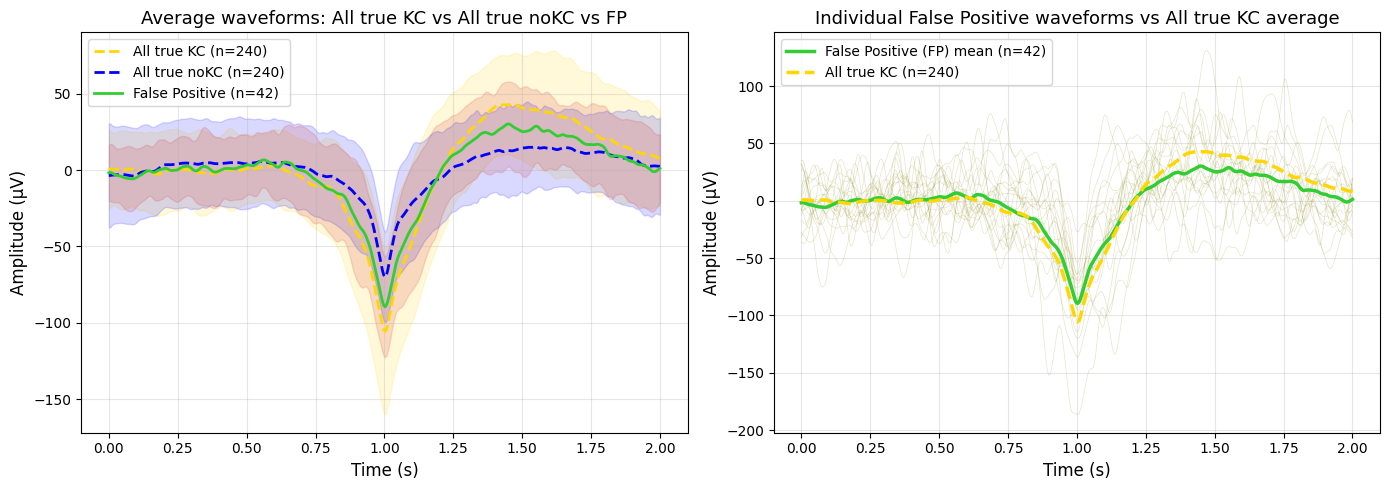


FP 'Both noKC' samples plotted: 42
TP samples for reference: 196
TN samples for reference: 182


In [171]:
plot_fp_morphology(df_overall, df_model_results, fs=200)

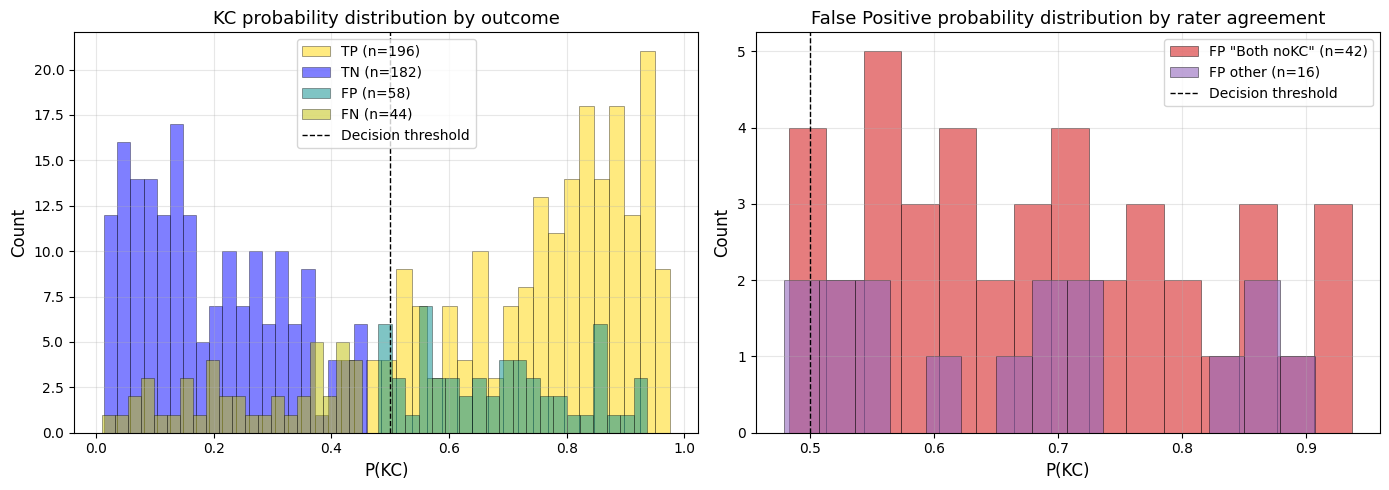


Probability summary by outcome:
  TP (n=196): mean=0.778, median=0.814, std=0.138, range=[0.459, 0.975]
  TN (n=182): mean=0.189, median=0.156, std=0.122, range=[0.014, 0.461]
  FP (n=58): mean=0.680, median=0.668, std=0.134, range=[0.479, 0.937]
  FN (n=44): mean=0.268, median=0.267, std=0.133, range=[0.011, 0.452]

  FP 'Both noKC' (n=42): mean=0.684, median=0.668
    High confidence (>0.7): 19 (45.2%)
    Mid confidence (0.5-0.7): 19 (45.2%)


In [155]:
plot_probability_distribution(df_model_results)

# Obsolete again

In [ ]:
# Distribution plot of predicted probabilities for KC, colored by prediction type (FP, FN)
# Add mean and sd
ax = sns.histplot(data=df_predictions,
                  x="Probability_KC",
                  hue="Prediction_Type",
                  common_norm=False,
                  bins=25,
                  stat="density",
                  kde=True)

plt.title("Probability of K-Complexes by Prediction Type")
plt.xlabel("Predicted Probability of KC")
plt.ylabel("Density")

# Move the seaborn-internal legend to a visible location
sns.move_legend(ax, loc="upper left", title="Prediction Type")
plt.ylim(0, 6.5)  # start y-axis at 0
plt.show()

In [ ]:
# Distribution plot of predicted probabilities for KC, colored by prediction type (FP, FN)
# Add mean and sd
ax = sns.histplot(data=df_predictions[df_predictions["Prediction_Type"].isin(["FP", "FN"])],
                  x="Probability_KC",
                  hue="Prediction_Type",
                  common_norm=False,
                  bins=50,
                  stat="density",
                  kde=False)

plt.title("Probability of K-Complexes by Prediction Type")
plt.xlabel("Predicted Probability of KC")
plt.ylabel("Density")

# Move the seaborn-internal legend to a visible location
sns.move_legend(ax, loc="upper right", title="Prediction Type")

plt.show()

In [ ]:
df_predictions['Label'].value_counts()

In [ ]:
df_predictions[df_predictions["Prediction_Type"].isin(["FN"])]['Probability_KC'].describe()

In [ ]:
df_predictions[df_predictions["Prediction_Type"].isin(["FP"])]['Probability_KC'].describe()

In [ ]:
df_predictions["Prediction_Type"].value_counts()

In [ ]:
fn_mask = df_predictions["Prediction_Type"] == "FN"
tp_mask = df_predictions["Prediction_Type"] == "TP"

print("=== FN Agreement Distribution ===")
print(df_predictions.loc[fn_mask, "Agreement"].value_counts(normalize=True))

print("\n=== TP Agreement Distribution ===")
print(df_predictions.loc[tp_mask, "Agreement"].value_counts(normalize=True))

# Single-expert breakdown
print("\n=== FN: CG only ===")
print(((df_predictions.loc[fn_mask, "CG"] == 1) & (df_predictions.loc[fn_mask, "LG"] == 0)).sum())
print("\n=== FN: LG only ===")
print(((df_predictions.loc[fn_mask, "CG"] == 0) & (df_predictions.loc[fn_mask, "LG"] == 1)).sum())
print("\n=== FN: Both experts ===")
print(((df_predictions.loc[fn_mask, "CG"] == 1) & (df_predictions.loc[fn_mask, "LG"] == 1)).sum())

In [ ]:
# fp_probs = df_predictions[df_predictions['Prediction_Type'] == 'FN']['Probability_KC'].values

# fp_probs_sorted = np.sort(fp_probs)

# plt.figure(figsize=(8,5))
# plt.plot(fp_probs_sorted, marker='o', markersize=3)
# plt.xlabel("FP index (sorted)")
# plt.ylabel("Probability_KC")
# plt.title("Sorted False Positive Probabilities")
# plt.grid(True)
# plt.show()

# ranks = np.linspace(0, 1, len(fp_probs_sorted))

# plt.figure(figsize=(8,5))
# plt.plot(ranks, fp_probs_sorted)
# plt.xlabel("Normalized rank")
# plt.ylabel("Probability_KC")
# plt.title("FP Probability Distribution Curve")
# plt.grid(True)
# plt.show()

# from numpy import gradient

# first_derivative = gradient(fp_probs_sorted)
# second_derivative = gradient(first_derivative)

elbow_index = np.argmax(second_derivative)
elbow_threshold = fp_probs_sorted[elbow_index]

print("Estimated inflection threshold:", elbow_threshold)

In [ ]:
print('Mean probability of the KC labeled to be a KC:')
df_predictions[df_predictions['Label']=='KC']['Probability_KC'].mean()

In [ ]:
print('Mean probability of the noKC labeled to be a noKC:')
df_predictions[df_predictions['Label']=='noKC']['Probability_noKC'].mean()

In [ ]:
plot_columns = [col for col in df_predictions.columns if col not in ['Subject', 'Label', 'Flag', 'Agreement', 'CG', 'LG', 'Predicted_Label',
       'Probability_KC', 'Probability_noKC', 'Prediction_Type']]

In [ ]:
plt.figure(figsize=(8,5))
false_noKC = df_predictions[df_predictions['Prediction_Type']=='FN'][plot_columns]
KC = df_predictions[df_predictions['Label']=='KC'][plot_columns]
noKC = df_predictions[df_predictions['Label']=='noKC'][plot_columns]
false_noKC = scale_values(false_noKC).values
KC = scale_values(KC).values
noKC = scale_values(noKC).values

t = np.linspace(0,2,400)

for wave in false_noKC:
    plt.plot(t, wave, color='green', alpha=0.25, linewidth=0.5)
print('Number of FN: ',len(false_noKC))

plt.plot(t, np.mean(false_noKC, axis=0), 
             color='green', linewidth=2, label='Mean False Negative with probability')
    
plt.plot(t, np.mean(KC, axis=0), 'y--', label = 'KC mean')
plt.plot(t, np.mean(noKC, axis=0), 'b--', label = 'No KC mean')

plt.title(f'False Negative vs KC vs No KC (scaled)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [norm]')
plt.ylim(-3,3)
plt.legend()
plt.show()

# for wave in false_noKC:
#     plt.figure(figsize=(8,5))
#     plt.plot(t, wave, color='green', alpha=1, linewidth=1)
#     plt.plot(t, np.mean(true_KC, axis=0), 'y--', label = 'True Positive mean')
#     plt.xlabel('Time [s]')
#     plt.ylabel('Amplitude [μV]')
#     plt.ylim(-150,150)
#     plt.legend()
#     plt.show()

In [ ]:
plt.figure(figsize=(8,5))
false_KC = df_predictions[df_predictions['Prediction_Type']=='FP'][plot_columns]
KC = df_predictions[df_predictions['Label']=='KC'][plot_columns]
noKC = df_predictions[df_predictions['Label']=='noKC'][plot_columns]
false_KC = scale_values(false_KC).values
KC = scale_values(KC).values
noKC = scale_values(noKC).values

t = np.linspace(0,2,400)

for wave in false_KC:
    plt.plot(t, wave, color='palegreen', alpha=0.1, linewidth=0.5)
print('Number of FP: ',len(false_KC))

plt.plot(t, np.mean(false_KC, axis=0), 
             color='darkolivegreen', linewidth=2, label='Mean False Positive')
    
plt.plot(t, np.mean(KC, axis=0), 'y--', label = 'KC mean')
plt.plot(t, np.mean(noKC, axis=0), 'b--', label = 'No KC mean')

plt.title(f'False Positive vs KC vs No KC (scaled)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [μV]')
plt.ylim(-3,3)
plt.legend()
plt.show()

for wave in false_KC[:5]:
    plt.figure(figsize=(8,5))
    plt.plot(t, wave, color='green', alpha=1, linewidth=1)
    plt.plot(t, np.mean(KC, axis=0), 'y--', label = 'KC mean')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude [μV]')
    plt.ylim(-3,3)
    plt.legend()
    plt.show()

## Check if FP can be corrected

In [ ]:
from fastdtw import fastdtw

kc_template = X_overall_scaled[y_overall == 'KC'].mean(axis=0)

In [ ]:
true_positive = scale_values(df_predictions[df_predictions['Prediction_Type']=='TP'][plot_columns]).values
false_positive = scale_values(df_predictions[df_predictions['Prediction_Type']=='FP'][plot_columns]).values
false_negative = scale_values(df_predictions[df_predictions['Prediction_Type']=='FN'][plot_columns]).values

In [ ]:
plt.figure(figsize=(8,5))
for wave in false_positive:
    plt.plot(t, wave, color='yellow', alpha=0.1, linewidth=0.5)
plt.plot(t, kc_template, color='red', alpha=1, linewidth=1, label='KC template')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [norm]')
plt.ylim(-3,3)
plt.legend()
plt.show()

In [ ]:
def cosine_similarity_to_template(X, template, eps=1e-8):
    num = X @ template
    den = (np.linalg.norm(X, axis=1) * np.linalg.norm(template) + eps)
    return num / den

cos_scores_false = cosine_similarity_to_template(false_KC, kc_template)
cos_scores_true = cosine_similarity_to_template(KC, kc_template)

In [ ]:
# true_KC_corr = []
# for sig in true_KC:
#     true_KC_corr.append(np.correlate(sig, kc_template)[0])

# false_KC_corr = []
# for sig in false_KC:
#     false_KC_corr.append(np.correlate(sig, kc_template)[0])

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(cos_scores_true, bins=30, color='lightgreen', edgecolor='black')
plt.title('Correlation from KC Template for KCs')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.show()

In [ ]:
bimodal_1 = KC[cos_scores_true > 0.6]
bimodal_2 = KC[cos_scores_true <= 0.6]

bimodal_false_1 = false_KC[cos_scores_false > 0.6]
bimodal_false_2 = false_KC[cos_scores_false <= 0.6]

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Two types of KCs')
#plt.plot(t, np.mean(bimodal_1, axis=0), color='blue', alpha=1, linewidth=1, label='KC with high template correlation')
plt.plot(t, np.mean(bimodal_2, axis=0), color='black', alpha=1, linewidth=1, label='KC with low template correlation')
plt.plot(t, np.mean(bimodal_false_2, axis=0), color='orange', linewidth=1, label='False Negative with low template correlation')
#plt.plot(t, np.mean(bimodal_false_1, axis=0), color='green', linewidth=1, label='False Negative with high template correlation')
plt.plot(t, KC.mean(axis=0), color='mediumblue', linestyle='--', label='KC mean')
plt.plot(t, noKC.mean(axis=0), color='red', linestyle='--', label='No KC mean')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [norm]')
plt.ylim(-3,3)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Two types of KCs')
# for sig in bimodal_1:
#     plt.plot(t, sig, color='blue', alpha=0.1, linewidth=0.5)
for sig in bimodal_2:
    plt.plot(t, sig, color='yellow', alpha=0.5, linewidth=0.5)
#plt.plot(t, np.mean(bimodal_1, axis=0), color='blue', alpha=1, linewidth=1)
plt.plot(t, np.mean(bimodal_2, axis=0), color='black', alpha=1, linewidth=1)
plt.plot(t, np.mean(bimodal_false_2, axis=0), color='orange', linewidth=1)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [norm]')
plt.ylim(-3,3)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Two types of KCs')
for sig in bimodal_1:
    plt.plot(t, sig, color='blue', alpha=0.1, linewidth=0.5)
# for sig in bimodal_2:
#     plt.plot(t, sig, color='yellow', alpha=0.5, linewidth=0.5)
plt.plot(t, np.mean(bimodal_1, axis=0), color='black', alpha=1, linewidth=1)
#plt.plot(t, np.mean(bimodal_2, axis=0), color='black', alpha=1, linewidth=1)
plt.plot(t, np.mean(bimodal_false_1, axis=0), color='green', linewidth=1)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [norm]')
plt.ylim(-3,3)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(cos_scores_false, bins=30, color='salmon', edgecolor='black')
plt.title('Correlation from KC Template for False Positives')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.show()


In [ ]:
plt.figure(figsize=(10,5))
candidates = df_predictions[(df_predictions['Probability_KC']<0.65) & (df_predictions['Prediction_Type']=='FP')][plot_columns].values
true_KC = df_predictions[df_predictions['Prediction_Type']=='TP'][plot_columns].values
true_noKC = df_predictions[df_predictions['Prediction_Type']=='TN'][plot_columns].values

for wave in candidates:
    plt.plot(t, wave, color='#288D8A', alpha=0.5, linewidth=0.5)
print('Number of FP with probability < 0.65: ',len(candidates))

plt.plot(t, np.mean(candidates, axis=0), 
             color='#288D8A', linewidth=2, label='Mean False Positive with probability < 0.65')
    
plt.plot(t, np.mean(true_KC, axis=0), 'y--', label = 'True Positive mean')
plt.plot(t, np.mean(true_noKC, axis=0), 'b--', label = 'True Negative mean')

plt.title(f'Low probability False Positive vs True Positive')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [μV]')
plt.ylim(-150,150)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
candidates = df_predictions[(df_predictions['Probability_KC']<0.65) & (df_predictions['Prediction_Type']=='FP')][plot_columns].values
true_KC = df_predictions[df_predictions['Prediction_Type']=='TP'][plot_columns].values
true_noKC = df_predictions[df_predictions['Prediction_Type']=='TN'][plot_columns].values

for wave in candidates:
    plt.plot(t, wave, color='#288D8A', alpha=0.5, linewidth=0.5)
print('Number of FP with probability < 0.65: ',len(candidates))

plt.plot(t, np.mean(candidates, axis=0), 
             color='#288D8A', linewidth=2, label='Mean False Positive with probability < 0.65')
    
plt.plot(t, np.mean(true_KC, axis=0), 'y--', label = 'True Positive mean')
plt.plot(t, np.mean(true_noKC, axis=0), 'b--', label = 'True Negative mean')

plt.title(f'Low probability False Positive vs True Positive')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [μV]')
plt.ylim(-150,150)
plt.legend()
plt.show()


In [ ]:
for wave in TP_waves:
    plt.figure(figsize=(8,5))
    plt.plot(t, wave, color='olive', alpha=1, linewidth=2)
    plt.plot(t, np.mean(TP_waves, axis=0), color='black', label = 'True Positive mean')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude [μV]')
    plt.ylim(-150,150)
    plt.legend()
    plt.show()

## Obsolete

### Weighted Classifier

In [ ]:
# # Fit the models.
# sample_weight = np.ones(len(X_overall_scaled2))
# index_KCs = np.where(y_overall == 'KC')
# sample_weight[index_KCs] = np.ones(len(index_KCs)) * 10

# # This model does not take into account sample weights.
# clf_no_weights = svm.NuSVC(nu=0.127, kernel='rbf', gamma='scale')
# clf_no_weights.fit(X_overall_scaled2, y_overall)

# # This other model takes into account some dedicated sample weights.
# clf_weights = svm.NuSVC(nu=0.127, kernel='rbf', gamma='scale')
# clf_weights.fit(X_overall_scaled2, y_overall, sample_weight=sample_weight)

In [ ]:
def run_weighted_SVC(X, y, weight=10):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    sample_weight = np.ones(len(X_train))
    index_KCs = np.where(y_train == 'KC')
    sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    
    #KERNEL
    scores = []
    kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
    for k in kernels:
        score = svm.SVC(kernel=k).fit(X_train, y_train, sample_weight=sample_weight).score(X_test, y_test)
        scores.append(score)
    plt.plot(kernels, scores)
    plt.title('SVM type of kernel comparison')
    plt.ylabel('Accuracy')
    plt.show()
    kernel_selected = kernels[scores.index(max(scores))]
    print(f'Kernel selected: "{kernel_selected}"')

    #C
    scores = []
    Cs = np.linspace(0.1,0.9,15)
    for c in Cs:
        score = svm.SVC(C=c, kernel=kernel_selected).fit(X_train, y_train, sample_weight=sample_weight).score(X_test, y_test)
        scores.append(score)

    plt.plot(Cs, scores)
    plt.title('SVM C parameter comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('C')
    plt.show()
    C_selected = Cs[scores.index(max(scores))]
    print(f'C selected: "{C_selected}"')

    #Gamma
    scores = []
    gammas = ['scale', 'auto']
    for g in gammas:
        score = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=g).fit(X_train, y_train,sample_weight=sample_weight).score(X_test, y_test)
        scores.append(score)
    plt.plot(gammas, scores)
    plt.title('SVM gamma parameter comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('gamma')
    plt.show()
    gamma_selected = gammas[scores.index(max(scores))]
    print(f'Gamma selected: "{gamma_selected}"')

    #Check performance of method
    print('PERFORMANCE:')
    print('Crossvalidation x10')

    clf = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=gamma_selected)
    for sc in ('accuracy','f1_macro','recall_macro'):
        scores = cross_val_score(clf, X, y, cv=10, scoring=sc)
        print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
    
    cv_results = cross_validate(clf, X, y, cv=10,
                            scoring=confusion_matrix_scorer)
                            

    TP = round(float(np.mean(cv_results['test_tp'])),2)
    FP = round(float(np.mean(cv_results['test_fp'])),2)
    FN = round(float(np.mean(cv_results['test_fn'])),2)
    TN = round(float(np.mean(cv_results['test_tn'])),2)

    cm_num = np.array([[TP, FN],[FP, TN]]).T

    clf.fit(X_train, y_train, sample_weight=sample_weight)
    y_pred = clf.predict(X_test)

    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

    t = np.linspace(0,2,2*200)
    plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
    plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
    plt.legend()
    plt.title('KC predicted vs KC true')
    plt.show()

    t = np.linspace(0,2,2*200)
    plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
    plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
    plt.legend()
    plt.title('noKC predicted vs noKC true')
    plt.show()

    print(f"svm.SVC(C={C_selected}, kernel={kernel_selected}, gamma={gamma_selected})")

In [ ]:
def run_weighted_nuSVC(X, y, weight=10):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    sample_weight = np.ones(len(X_train))
    index_KCs = np.where(y_train == 'KC')
    sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    l = len(y) #number of training samples
    l_pos = len(np.where(y == 'KC')[0]) #number of KC
    l_neg = len(np.where(y == 'noKC')[0]) #number of noKC
    max_nu = min(l_pos/l,l_neg/l)
    
    #KERNEL
    scores = []
    kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
    for k in kernels:
        score = svm.NuSVC(kernel=k).fit(X_train, y_train, sample_weight=sample_weight).score(X_test, y_test)
        scores.append(score)
    plt.plot(kernels, scores)
    plt.title('SVM type of kernel comparison')
    plt.ylabel('Accuracy')
    plt.show()
    kernel_selected = kernels[scores.index(max(scores))]
    print(f'Kernel selected: "{kernel_selected}"')

    #Nu
    scores = []
    Nus = np.linspace(0.1,max_nu*2,9*10)
    for nu in Nus:
        score = svm.NuSVC(nu=nu, kernel=kernel_selected).fit(X_train, y_train, sample_weight=sample_weight).score(X_test, y_test)
        scores.append(score)

    plt.plot(Nus, scores)
    plt.title('SVM Nu parameter comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('Nu')
    plt.show()
    nu_selected = Nus[scores.index(max(scores))]
    print(f'Nu selected: "{nu_selected}"')

    #Gamma
    scores = []
    gammas = ['scale', 'auto']
    for g in gammas:
        score = svm.NuSVC(nu=nu_selected, kernel=kernel_selected, gamma=g).fit(X_train, y_train,sample_weight=sample_weight).score(X_test, y_test)
        scores.append(score)
    plt.plot(gammas, scores)
    plt.title('SVM gamma parameter comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('gamma')
    plt.show()
    gamma_selected = gammas[scores.index(max(scores))]
    print(f'Gamma selected: "{gamma_selected}"')

    #Check performance of method
    print('PERFORMANCE:')
    print('Crossvalidation x10')

    clf = svm.NuSVC(nu=nu_selected, kernel=kernel_selected, gamma=gamma_selected)
    for sc in ('accuracy','f1_macro','recall_macro'):
        scores = cross_val_score(clf, X, y, cv=10, scoring=sc)
        print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
    
    cv_results = cross_validate(clf, X, y, cv=10,
                            scoring=confusion_matrix_scorer)

    TP = round(float(np.mean(cv_results['test_tp'])),2)
    FP = round(float(np.mean(cv_results['test_fp'])),2)
    FN = round(float(np.mean(cv_results['test_fn'])),2)
    TN = round(float(np.mean(cv_results['test_tn'])),2)

    cm_num = np.array([[TP, FN],[FP, TN]]).T

    clf.fit(X_train, y_train, sample_weight=sample_weight)
    y_pred = clf.predict(X_test)

    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

    t = np.linspace(0,2,2*200)
    plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
    plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
    plt.legend()
    plt.title('KC predicted vs KC true')
    plt.show()

    t = np.linspace(0,2,2*200)
    plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
    plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
    plt.legend()
    plt.title('noKC predicted vs noKC true')
    plt.show()

    print(f"svm.NuSVC(C={nu_selected}, kernel={kernel_selected}, gamma={gamma_selected})")

In [ ]:
proportion_KC_noKC = (y_overall == 'noKC').sum()/(y_overall == 'KC').sum()
proportion_KC_noKC

#### SVM

In [ ]:
run_weighted_SVC(X=X_overall_scaled, y=y_overall, weight=proportion_KC_noKC)

In [ ]:
run_weighted_SVC(X=X_overall_scaled2, y=y_overall, weight=proportion_KC_noKC)

In [ ]:
run_weighted_SVC(X=X_overall_scaled, y=y_overall, weight=1)

In [ ]:
run_weighted_SVC(X=X_overall_scaled2, y=y_overall, weight=1)

In [ ]:
run_weighted_SVC(X=X_model_scaled, y=y_model, weight=1)

In [ ]:
run_weighted_SVC(X=X_model_scaled2, y=y_model, weight=1)

#### nu-SVM

In [ ]:
run_weighted_nuSVC(X=X_overall_scaled, y=y_overall, weight=proportion_KC_noKC)

In [ ]:
run_weighted_nuSVC(X=X_overall_scaled2, y=y_overall, weight=proportion_KC_noKC)

In [ ]:
run_weighted_nuSVC(X=X_overall_scaled, y=y_overall, weight=1)

In [ ]:
run_weighted_nuSVC(X=X_overall_scaled2, y=y_overall, weight=1)

In [ ]:
run_weighted_nuSVC(X=X_model_scaled, y=y_model, weight=1)

In [ ]:
run_weighted_nuSVC(X=X_model_scaled2, y=y_model, weight=1)

### Balanced Bagging Classifier

In [ ]:
# from scipy.stats import loguniform
# from sklearn.metrics import make_scorer, recall_score, accuracy_score

# l = len(y_overall)
# l_pos = len(np.where(y_overall == 'KC')[0]) #number of KC
# l_neg = len(np.where(y_overall == 'noKC')[0]) #number of noKC
# max_nu = min(l_pos/l,l_neg/l)
# X_train, X_test, y_train, y_test = train_test_split(X_overall_scaled2, y_overall, test_size=0.2, random_state=10)

# param_grid = {
#     "nu": loguniform(1e-4, max_nu*2),
#     "gamma": loguniform(1e-4, 1),
#     "kernel": ['poly', 'rbf', 'sigmoid'],
#     'class_weight': ['balanced', None]
# }

# def combined_score(y_true, y_pred):
#     acc = accuracy_score(y_true, y_pred)
#     recall_kc = recall_score(y_true, y_pred, pos_label='KC')
#     return acc + 0.5 * recall_kc

# combined_scorer = make_scorer(combined_score, greater_is_better=True)

# clf = RandomizedSearchCV(
#     estimator=svm.NuSVC(),
#     param_distributions=param_grid,
#     n_iter=10,
#     scoring=combined_scorer,
#     random_state=42
# )

# clf = clf.fit(X_train, y_train)

# clf.best_params_

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X_overall_scaled2, y_overall, test_size=0.2, random_state=10)

# # Define your combined scorer
# def combined_score(y_true, y_pred):
#     acc = accuracy_score(y_true, y_pred)
#     recall_kc = recall_score(y_true, y_pred, pos_label='KC')
#     return acc + 0.3 * recall_kc

# combined_scorer = make_scorer(combined_score, greater_is_better=True)

# # Calculate max nu
# l = len(y_overall)
# l_pos = len(np.where(y_overall == 'KC')[0])
# l_neg = len(np.where(y_overall == 'noKC')[0])
# max_nu = min(l_pos/l, l_neg/l)

# # Define the model
# bbc = BalancedBaggingClassifier(
#     estimator=svm.NuSVC(),
#     n_estimators=10,
#     random_state=42,
#     n_jobs=-1
# )

# # Define parameter grid
# param_grid = {
#     "estimator__nu": loguniform(1e-4, max_nu * 2),
#     "estimator__gamma": loguniform(1e-4, 1),
#     "estimator__kernel": ['poly', 'rbf', 'sigmoid'],
#     "n_estimators": [5, 10, 15]
# }

# # Randomized search
# clf = RandomizedSearchCV(
#     estimator=bbc,
#     param_distributions=param_grid,
#     n_iter=15,
#     scoring=combined_scorer,
#     cv=5,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

# clf.fit(X_train, y_train)


In [ ]:
# best_model = clf.best_estimator_
# best_model


In [ ]:
best_model_lsym = BalancedBaggingClassifier(estimator=svm.NuSVC(gamma=0.054082165807184904,
                                          kernel='poly',
                                          nu=0.04042125351469507),
                          n_estimators=15, n_jobs=-1, random_state=42)

In [ ]:
best_model = best_model_lsym

In [ ]:
def plot_false_positive_vs_trues(X,y,clf):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    clf.fit(X_train, y_train)
    
    probability = clf.predict_proba(X)
    y_pred = clf.predict(X)

    KC_prob = probability[:,0]
    #noKC_prob = probability[:,1]

    y_false_positive = X.iloc[np.where((y_pred == 'KC') & (y == 'noKC'))]
    y_high_pred_false_positive = X.iloc[np.where((KC_prob > 0.75) & (y == 'noKC'))]
    #y_false_negative = X.iloc[np.where((noKC_prob > 0.5) & (y == 'KC'))]

    plt.figure(figsize=(10,5))
    plt.plot(t, X.iloc[np.where(y_pred == 'KC')].mean(axis=0), 
            color='blue', 
            linewidth = 2,
            label='Predicted KC')
    plt.plot(t, X.iloc[np.where(y == 'KC')].mean(axis=0), '--c', label='True KC')
    plt.plot(t, X.iloc[np.where(y_pred == 'noKC')].mean(axis=0), 
            color='orange', 
            linewidth = 2,
            label='Predicted noKC')
    plt.plot(t, X.iloc[np.where(y == 'noKC')].mean(axis=0), '--r', label='True noKC')
    plt.plot(t, y.mean(axis=0), label = f'False Positives (N={len(y_false_positive)})', color = 'limegreen')
    plt.plot(t, y_high_pred_false_positive.mean(axis=0), label = f'High probability False Positive (N={len(y_high_pred_false_positive)})', color = 'maroon')
    plt.legend()
    plt.show()

#     plt.figure(figsize=(10,5))
#     for i in range(len(y_false_positive)):
#         sig = y_false_positive.iloc[i]
#         plt.plot(t, sig, alpha=0.25, linewidth=0.25, color='black')

#     plt.plot(t, y_false_positive.mean(axis=0), label = 'False Positives', color = 'limegreen')
#     plt.plot(t, X.iloc[np.where(y_model == 'KC')].mean(axis=0), 'c', label='True KC')
#     plt.legend()
#     plt.show()

    # for i in range(len(y_false_negative)):
    #     plt.figure(figsize=(10,5))
    #     sig = y_false_negative.iloc[i]
    #     plt.plot(t,sig, alpha=0.75, linewidth=0.5, color='black')
    #     plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
    #     plt.legend()
    #     plt.show()
        

    # plt.plot(t, y_false_negative.mean(axis=0), label = 'False Negative', color = 'limegreen')
    # plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), 'c', label='True KC')
    # plt.legend()
    # plt.show()

In [ ]:
plot_false_positive_vs_trues(X_model_scaled2, y_model, best_model_lsym)

In [ ]:
# probability = best_model.predict_proba(X_overall_scaled2)
# y_pred = best_model.predict(X_overall_scaled2)

# KC_prob = probability[:,0]
# noKC_prob = probability[:,1]

# y_false_positive_high_prob = X_overall_scaled2.iloc[np.where((KC_prob >= 0.6) & (y_overall == 'noKC'))]
# y_false_positive_low_prob = X_overall_scaled2.iloc[np.where((KC_prob >= 0.5) & (KC_prob < 0.6) & (y_overall == 'noKC'))]

# plt.figure(figsize=(10,5))
# # plt.plot(t, X_overall_scaled2.iloc[np.where(y_pred == 'KC')].mean(axis=0), 
# #          color='blue', 
# #          linewidth = 2,
# #          label='Predicted KC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'KC')].mean(axis=0), '--c', label='True KC')
# plt.plot(t, X_overall_scaled2.iloc[np.where(y_pred == 'noKC')].mean(axis=0), 
#          color='orange', 
#          linewidth = 2,
#          label='Predicted noKC')
# # plt.plot(t, X_overall_scaled2.iloc[np.where(y_overall == 'noKC')].mean(axis=0), '--r', label='True noKC')
# #plt.plot(t, X_overall_train.mean(axis=0), '--k', label='Average')
# plt.plot(t, y_false_positive_high_prob.mean(axis=0), label = f'False Positives high prob(N={len(y_false_positive_high_prob)})', color = 'limegreen')
# plt.plot(t, y_false_positive_low_prob.mean(axis=0), label = f'False Positives low prob(N={len(y_false_positive_low_prob)})', color = 'green')
# # plt.plot(t, y_false_negative.mean(axis=0), label = f'False Negative (N={len(y_false_negative)})', color = 'maroon')
# plt.legend()
# plt.show()

In [ ]:
# def run_BalancedBaggingClassifier(X, y, mode):
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
#         scores = []        
#         if mode == 'NuSVM':    
#                 l = len(y) #number of training samples
#                 l_pos = len(np.where(y == 'KC')[0]) #number of KC
#                 l_neg = len(np.where(y == 'noKC')[0]) #number of noKC
#                 max_nu = min(l_pos/l,l_neg/l)
#                 #Kernel
#                 kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
#                 for k in kernels:
#                         clf = svm.NuSVC(kernel=k, nu=max_nu*2).fit(X_train, y_train)
#                         # clf = BalancedBaggingClassifier(base_classifier,
#                         #                                     n_estimators = 5,
#                         #                                     sampling_strategy='auto',  
#                         #                                     replacement=False,  # Whether to sample with or without replacement
#                         #                                     random_state=42).fit(X_train, y_train)
#                         y_pred = clf.predict(X_test)
#                         score = recall_score(y_test, y_pred, pos_label='KC')
#                         scores.append(score)
#                 kernel_selected = kernels[scores.index(max(scores))]
#                 print(f'Kernel selected: "{kernel_selected}"')
#                 #Nu
#                 scores = []
#                 Nus = np.linspace(0.001,max_nu*2,9*10)
#                 for nu in Nus:
#                         clf = svm.NuSVC(nu=nu, kernel='rbf', gamma=0.002).fit(X_train, y_train)
#                         # clf = BalancedBaggingClassifier(base_classifier,
#                         #                                     n_estimators = 5,
#                         #                                     sampling_strategy='auto',  
#                         #                                     replacement=False,  # Whether to sample with or without replacement
#                         #                                     random_state=42).fit(X_train, y_train)
#                         y_pred = clf.predict(X_test)
#                         score = recall_score(y_test, y_pred, pos_label='KC')
#                         scores.append(score)
#                 nu_selected = Nus[scores.index(max(scores))]
#                 print(f'Nu selected: "{nu_selected}"')
#                 #Gamma
#                 scores = []
#                 gammas = np.linspace(1/500, 3, 10)
#                 for g in gammas:
#                         clf = svm.NuSVC(nu=nu, kernel=kernel_selected, gamma=g).fit(X_train, y_train)
#                         # clf = BalancedBaggingClassifier(base_classifier,
#                         #                                     n_estimators = 5,
#                         #                                     sampling_strategy='auto',  
#                         #                                     replacement=False,  # Whether to sample with or without replacement
#                         #                                     random_state=42).fit(X_train, y_train)
#                         y_pred = clf.predict(X_test)
#                         score = recall_score(y_test, y_pred, pos_label='KC')
#                         scores.append(score)
#                 gamma_selected = gammas[scores.index(max(scores))]
#                 print(f'Gamma selected: "{gamma_selected}"')
#                 base_classifier = svm.NuSVC(nu=nu_selected, kernel=kernel_selected, gamma=gamma_selected)
#                 print(f"Nu-SVM Model selected: svm.NuSVC(nu={nu_selected}, kernel='{kernel_selected}', gamma='{gamma_selected}')")

#         elif mode == 'SVM':
#                 #Kernel
#                 kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
#                 for k in kernels:
#                         score = svm.SVC(kernel=k).fit(X_train, y_train).recall_score(X_test, y_test)
#                         scores.append(score)
#                 kernel_selected = kernels[scores.index(max(scores))]
#                 print(f'Kernel selected: "{kernel_selected}"')
#                 #C
#                 scores = []
#                 Cs = np.linspace(0.1,0.9,9*10)
#                 for c in Cs:
#                         score = svm.SVC(C=c, kernel=kernel_selected).fit(X_train, y_train).score(X_test, y_test)
#                         scores.append(score)
#                 C_selected = Cs[scores.index(max(scores))]
#                 print(f'C selected: "{C_selected}"')

#                 #Gamma
#                 scores = []
#                 gammas = ['scale', 'auto']
#                 for g in gammas:
#                         score = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=g).fit(X_train, y_train).score(X_test, y_test)
#                         scores.append(score)
#                 gamma_selected = gammas[scores.index(max(scores))]
#                 print(f'Gamma selected: "{gamma_selected}"')
#                 base_classifier = svm.SVC(C=C_selected, kernel=kernel_selected, gamma=gamma_selected)
#                 print(f"SVM Model selected: svm.SVC(C={C_selected}, kernel='{kernel_selected}', gamma='{gamma_selected}')")

    
#         balanced_bagging_classifier = BalancedBaggingClassifier(base_classifier,
#                                                             n_estimators = 5,
#                                                             sampling_strategy='auto',  
#                                                             replacement=False,  # Whether to sample with or without replacement
#                                                             random_state=42)

#         for sc in ('accuracy','f1_macro','recall_macro'):
#                 scores = cross_val_score(balanced_bagging_classifier, X, y, cv=10, scoring=sc)#, fit_params={'sample_weight': sample_weight})
#                 print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
                
#         cv_results = cross_validate(balanced_bagging_classifier, X, y, cv=10,
#                                 scoring=confusion_matrix_scorer)

#         TP = round(float(np.mean(cv_results['test_tp'])),2)
#         FP = round(float(np.mean(cv_results['test_fp'])),2)
#         FN = round(float(np.mean(cv_results['test_fn'])),2)
#         TN = round(float(np.mean(cv_results['test_tn'])),2)

#         cm_num = np.array([[TN, FP],[FN, TP]])

#         # Fit the model
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
#         balanced_bagging_classifier.fit(X_train, y_train)

#         # Make predictions
#         y_pred = balanced_bagging_classifier.predict(X_test)

#         cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
#         cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

#         ConfusionMatrixDisplay(cm_num, display_labels=['noKC','KC'] ).plot(cmap='Blues', colorbar=False, values_format='.1f')
#         plt.title('Average number of predicted')
#         plt.show()
#         ConfusionMatrixDisplay(cm_normalized_true, display_labels=['noKC','KC'] ).plot(cmap='Blues', colorbar=False)
#         plt.title('Normalized by true labels')
#         plt.show()
#         ConfusionMatrixDisplay(cm_normalized_pred, display_labels=['noKC','KC'] ).plot(cmap='Blues', colorbar=False)
#         plt.title('Normalized by predicted labels')
#         plt.show()

#         t = np.linspace(0,2,2*200)
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
#         plt.legend()
#         plt.title('KC predicted vs KC true')
#         plt.show()

#         t = np.linspace(0,2,2*200)
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
#         plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
#         plt.legend()
#         plt.title('noKC predicted vs noKC true')
#         plt.show()

In [ ]:
def run_best_model(X, y, clf):
    idxs = cross_validate(clf, X, y, cv=10, return_indices=True)['indices']
    idx_train = idxs['train'] 
    idx_test = idxs['test']

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []

    for i in range(len(idx_test)):
        X_train, X_test = X.loc[idx_train[i]], X.loc[idx_test[i]]
        y_train, y_test = y.loc[idx_train[i]], y.loc[idx_test[i]]
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])

    print()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    y_pred = clf.predict(X_test)
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()



In [ ]:
run_best_model(X_overall_scaled2, y_overall, clf=best_model)

In [ ]:
run_best_model(X_model_scaled2, y_model, clf=best_model_lsym)

In [ ]:
# run_best_model(X_model_scaled2, y_model, clf= svm.NuSVC(gamma=0.054, kernel='poly', nu=0.04))

In [ ]:
# l = len(y_overall) #number of training samples
# l_pos = len(np.where(y_overall == 'KC')[0]) #number of KC
# l_neg = len(np.where(y_overall == 'noKC')[0]) #number of noKC
# nu_selected_corrected = min(l_pos/l,l_neg/l)
# print('Nu', nu_selected_corrected)

# base_classifier = svm.NuSVC(nu=nu_selected_corrected ,kernel='rbf', gamma='scale')
# balanced_bagging_classifier = BalancedBaggingClassifier(base_classifier,
#                                                         n_estimators = 5,
#                                                         sampling_strategy='auto',  
#                                                         replacement=False,  # Whether to sample with or without replacement
#                                                         random_state=42)

# for sc in ('accuracy','f1_macro','recall_macro'):
#         scores = cross_val_score(balanced_bagging_classifier, X_overall_scaled2, y_overall, cv=10, scoring=sc)#, fit_params={'sample_weight': sample_weight})
#         print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
    
# cv_results = cross_validate(balanced_bagging_classifier, X_overall_scaled2, y_overall, cv=10,
#                         scoring=confusion_matrix_scorer)

# TP = round(float(np.mean(cv_results['test_tn'])),2)
# FP = round(float(np.mean(cv_results['test_fn'])),2)
# FN = round(float(np.mean(cv_results['test_fp'])),2)
# TN = round(float(np.mean(cv_results['test_tp'])),2)

# cm_num = np.array([[TP, FN],[FP, TN]])

# # Fit the model
# balanced_bagging_classifier.fit(X_overall_scaled2_train, y_overall_scaled2_train)

# # Make predictions
# y_pred = balanced_bagging_classifier.predict(X_overall_scaled2_test)

# print(classification_report(y_overall_scaled2_test, y_pred))

# cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
# cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

# ConfusionMatrixDisplay(cm_num, display_labels=balanced_bagging_classifier.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
# plt.title('Average number of predicted')
# plt.show()
# ConfusionMatrixDisplay(cm_normalized_true, display_labels=balanced_bagging_classifier.classes_ ).plot(cmap='Blues', colorbar=False)
# plt.title('Normalized by true labels')
# plt.show()
# ConfusionMatrixDisplay(cm_normalized_pred, display_labels=balanced_bagging_classifier.classes_ ).plot(cmap='Blues', colorbar=False)
# plt.title('Normalized by predicted labels')
# plt.show()

# t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(X_overall_scaled2_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
# plt.plot(t, np.mean(X_overall_scaled2_test.iloc[np.where(y_overall_scaled2_test == 'KC')], axis=0).values, label='True')
# plt.legend()
# plt.title('KC predicted vs KC true')
# plt.show()

# t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(X_overall_scaled2_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
# plt.plot(t, np.mean(X_overall_scaled2_test.iloc[np.where(y_overall_scaled2_test == 'noKC')], axis=0).values, label='True')
# plt.legend()
# plt.title('noKC predicted vs noKC true')
# plt.show()

In [ ]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# X_train, X_test, y_train, y_test = train_test_split(
#     X_overall_scaled2, y_overall, test_size=0.2, random_state=42)

# # Train a classification model (Random Forest as an example)
# model = svm.NuSVC(nu=0.08382022471910112, kernel='rbf', gamma='scale', probability=True)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# print(classification_report(y_test, y_pred))

# # Predict probabilities on the test set
# y_proba = model.predict_proba(X_test)[:, 0]

# # Set a threshold (initially 0.5)
# threshold = 0.5
# y_test_int = np.zeros(len(y_test))
# idx = np.where(y_test == 'KC')
# y_test_int[idx] = np.ones(len(idx))
# # Adjust threshold based on your criteria (e.g., maximizing F1-score)
# while threshold >= 0:
#     y_pred = (y_proba >= threshold).astype(int)
#     f1 = f1_score(y_test_int, y_pred)
#     acc = accuracy_score(y_test_int, y_pred)
#     rec = recall_score(y_test_int, y_pred)
#     prec = precision_score(y_test_int, y_pred)

#     print(f"Threshold: {threshold:.2f}, F1 Score: {f1:.2f}, Accuracy: {acc:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

#     # Move the threshold (you can customize the step size)
#     threshold -= 0.02

### NU-SVM

For binary classification, let’s say:

* 𝑙: total number of training samples

* 𝑙+: number of samples with label +1

* 𝑙−: number of samples with label -1

Then for nu to be feasible: $𝜈 ≤ min(\frac{𝑙+}{𝑙},\frac{𝑙−}{𝑙})$

In [ ]:
# def run_NuSVC(X, y):
#     # sample_weight = np.ones(len(X))
#     # index_KCs = np.where(y == 'KC')
#     # weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
#     # weight = 1 if weight < 1 else weight
#     # index_KCs = np.where(y == 'KC')[0]
#     # sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
#     # print('Weight applied:', weight)
    
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
#     # sample_weight_train = sample_weight[X_train.index]

#     # #KERNEL
#     # scores = []
#     # kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
#     # for k in kernels:
#     #     score = svm.NuSVC(kernel=k).fit(X_train, y_train, sample_weight=sample_weight_train).score(X_test, y_test)
#     #     scores.append(score)
#     # plt.plot(kernels, scores)
#     # plt.title('Nu-SVM type of kernel comparison')
#     # plt.ylabel('Accuracy')
#     # plt.show()
#     # kernel_selected = kernels[scores.index(max(scores))]
#     # print(f'Kernel selected: "{kernel_selected}"')

#     # #Nu
#     # scores = []
#     # nus = np.linspace(0.1,0.9,9*10)
#     # for nu in nus:
#     #     score = svm.NuSVC(nu=nu, kernel=kernel_selected).fit(X_train, y_train, sample_weight=sample_weight_train).score(X_test, y_test)
#     #     scores.append(score)

#     # plt.plot(nus, scores)
#     # plt.title('Nu-SVM Nu parameter comparison')
#     # plt.ylabel('Accuracy')
#     # plt.xlabel('Nu')
#     # plt.show()
#     # nu_selected = nus[scores.index(max(scores))]
#     # print(f'Nu selected: "{nu_selected}"')

#     # #Gamma
#     # scores = []
#     # gammas = ['scale', 'auto']
#     # for g in gammas:
#     #     score = svm.NuSVC(nu=nu_selected, kernel=kernel_selected, gamma=g).fit(X_train, y_train, sample_weight=sample_weight_train).score(X_test, y_test)
#     #     scores.append(score)
#     # plt.plot(gammas, scores)
#     # plt.title('Nu-SVM gamma parameter comparison')
#     # plt.ylabel('Accuracy')
#     # plt.xlabel('gamma')
#     # plt.show()
#     # gamma_selected = gammas[scores.index(max(scores))]
#     # print(f'Gamma selected: "{gamma_selected}"')

#     # print('PERFORMANCE:')
#     # print('Crossvalidation x10')

#     l = len(y) #number of training samples
#     l_pos = len(np.where(y == 'KC')[0]) #number of KC
#     l_neg = len(np.where(y == 'noKC')[0]) #number of noKC
#     nu_selected_corrected = min(l_pos/l,l_neg/l)
#     print('Nu selected:', nu_selected_corrected)
#     # nu_selected_corrected = 0.0672

#     clf = svm.NuSVC(nu=nu_selected_corrected, kernel='rbf', gamma='scale')
#     for sc in ('accuracy','f1_macro','recall_macro'):
#         scores = cross_val_score(clf, X, y, cv=10, scoring=sc, fit_params={'sample_weight': sample_weight})
#         print(sc, round(scores.mean(),2), '+-', round(scores.std(),2))
    
#     cv_results = cross_validate(clf, X, y, cv=10,
#                             scoring=confusion_matrix_scorer, fit_params={'sample_weight': sample_weight})

#     TP = round(float(np.mean(cv_results['test_tn'])),2)
#     FP = round(float(np.mean(cv_results['test_fn'])),2)
#     FN = round(float(np.mean(cv_results['test_fp'])),2)
#     TN = round(float(np.mean(cv_results['test_tp'])),2)

#     cm_num = np.array([[TP, FN],[FP, TN]])

#     clf.fit(X_train, y_train, sample_weight= sample_weight_train)
#     y_pred = clf.predict(X_test)

#     cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
#     cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

#     ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
#     plt.title('Average number of predicted')
#     plt.show()
#     ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
#     plt.title('Normalized by true labels')
#     plt.show()
#     ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
#     plt.title('Normalized by predicted labels')
#     plt.show()

#     t = np.linspace(0,2,2*200)
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
#     plt.legend()
#     plt.title('KC predicted vs KC true')
#     plt.show()

#     t = np.linspace(0,2,2*200)
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
#     plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
#     plt.legend()
#     plt.title('noKC predicted vs noKC true')
#     plt.show()

#     print(f"svm.NuSVC(nu={nu_selected_corrected}, kernel='rbf', gamma='scale')")

In [ ]:
# run_NuSVC(X_model_scaled2, y_model)

In [ ]:
# run_NuSVC(X_overall_scaled2, y_overall)

### Stratified kFold

In [ ]:
def run_StratifiedKFold(X, y, clf):
    print('--------------------- StratifiedKFold ---------------------')
    kf = StratifiedKFold(n_splits=10)

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []

    # Fit the models
    # sample_weight = np.ones(len(X))
    # index_KCs = np.where(y == 'KC')
    # weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
    # weight = 1 if weight < 1 else weight
    # sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    # print('Weight applied:', weight)

    print('PERFORMANCE:')
    for i, (train_index, test_index) in enumerate(kf.split(X, y)):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]
        # sample_weight_train = sample_weight[X_train.index]

        
        clf.fit(X_train, y_train)
        # clf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred = clf.predict(X_test)


        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])
        
        print(f'Iteration {i}')
        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('KC predicted vs KC true')
        # plt.show()

        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('noKC predicted vs noKC true')
        # plt.show()

    print()
    
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

def run_SVC_StratifiedKFold(X, y):
    clf = svm.SVC(C=0.7112359550561798, kernel='rbf', gamma='scale')
    balanced_bagging_classifier = BalancedBaggingClassifier(clf,
                                                            n_estimators = 5,
                                                            sampling_strategy='auto',  
                                                            replacement=False,  # Whether to sample with or without replacement
                                                            random_state=42)
    run_StratifiedKFold(X, y, balanced_bagging_classifier)

def run_NuSVC_StratifiedKFold(X, y, clf):
    # l = len(df_overall) #number of training samples
    # l_pos = len(df_overall[df_overall['Label'] == 'KC']) #number of KC
    # l_neg = len(df_overall[df_overall['Label'] == 'noKC']) #number of noKC
    # nu_selected_corrected = min(l_pos/l,l_neg/l) #* nu_selected
    # print('Nu corrected', nu_selected_corrected)
    # clf = NuSVC(gamma=0.045,nu=0.002,kernel='rbf')
    # #
    # balanced_bagging_classifier = BalancedBaggingClassifier(clf,
    #                                                         n_estimators = 10,
    #                                                         sampling_strategy='auto',  
    #                                                         replacement=False,  # Whether to sample with or without replacement
    #                                                         random_state=42)
    run_StratifiedKFold(X, y, clf)

In [ ]:
run_NuSVC_StratifiedKFold(X_overall_scaled2, y_overall, best_model)

In [ ]:
run_NuSVC_StratifiedKFold(X_model_scaled2, y_model, best_model_lsym)

In [ ]:
# run_SVC_StratifiedKFold(X_overall_scaled2, y_overall)

In [ ]:
# run_SVC_StratifiedKFold(X_model_scaled2, y_model.reset_index().drop(columns='index'))

### Stratified Shuffle Split

In [ ]:
def run_StratifiedShuffleSplit(X, y, clf):
    print('--------------------- StratifiedShuffleSplit ---------------------')
    sh = StratifiedShuffleSplit(n_splits=10, test_size=0.2)

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []
    # sample_weight = np.ones(len(X))
    # index_KCs = np.where(y == 'KC')
    # weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
    # sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    # print('Weight applied:', weight)
    
    print('PERFORMANCE:')
    for i, (train_index, test_index) in enumerate(sh.split(X, y)):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]
        # sample_weight_train = sample_weight[X_train.index]

        clf.fit(X_train, y_train)
        # clf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred = clf.predict(X_test)


        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])
        
        # print(f'Iteration {i}')
        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('KC predicted vs KC true')
        # plt.show()

        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('noKC predicted vs noKC true')
        # plt.show()

    print()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    y_pred = clf.predict(X_test)
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

def run_SVC_StratifiedShuffleSplit(X, y):
    clf = svm.SVC(C=0.7112359550561798, kernel='rbf', gamma='scale')
    balanced_bagging_classifier = BalancedBaggingClassifier(clf,
                                                            n_estimators = 5,
                                                            sampling_strategy='auto',  
                                                            replacement=False,  # Whether to sample with or without replacement
                                                            random_state=42)
    run_StratifiedShuffleSplit(X, y, balanced_bagging_classifier)

def run_NuSVC_StratifiedShuffleSplit(X, y, clf):
    # l = len(df_overall) #number of training samples
    # l_pos = len(df_overall[df_overall['Label'] == 'KC']) #number of KC
    # l_neg = len(df_overall[df_overall['Label'] == 'noKC']) #number of noKC
    # nu_selected_corrected = min(l_pos/l,l_neg/l) #* nu_selected
    # print('Nu corrected', nu_selected_corrected)
    # clf = svm.NuSVC(gamma=0.04, kernel='poly', nu=0.108)
    # #svm.NuSVC(gamma=0.019, kernel='poly', nu=0.108)
    # #svm.NuSVC(gamma=0.04, kernel='poly', nu=0.108)
    # balanced_bagging_classifier = BalancedBaggingClassifier(clf,
    #                                                         n_estimators = 5,
    #                                                         sampling_strategy='auto',  
    #                                                         replacement=False,  # Whether to sample with or without replacement
    #                                                         random_state=42)
    run_StratifiedShuffleSplit(X, y, clf)

In [ ]:
run_NuSVC_StratifiedShuffleSplit(X_overall_scaled2, y_overall, best_model)

In [ ]:
run_NuSVC_StratifiedShuffleSplit(X_model_scaled2, y_model, best_model_lsym)

In [ ]:
# run_NuSVC_StratifiedShuffleSplit(X_model_scaled2, y_model.reset_index().drop(columns='index'))

In [ ]:
# run_SVC_StratifiedShuffleSplit(X_overall_scaled2, y_overall)

### Group KFold

In [ ]:
groups = df_overall['Subject'].values
def run_GroupKFold(X, y, clf, groups):
    print('--------------------- GroupKFold ---------------------')
    gk = GroupKFold(n_splits=10)

    accuracy = []
    m = ['precision', 'recall', 'f1-score']
    metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
                'KC': {'precision': [], 'recall': [], 'f1-score': []}}
    TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []
    # sample_weight = np.ones(len(X))
    # index_KCs = np.where(y == 'KC')
    # weight = int(len(np.where(y=='noKC')[0])/len(np.where(y=='KC')[0]))//2
    # sample_weight[index_KCs] = np.ones(len(index_KCs)) * weight
    # print('Weight applied:', weight)
    
    print('PERFORMANCE:')
    for i, (train_index, test_index) in enumerate(gk.split(X, y, groups=groups)):
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]
        # sample_weight_train = sample_weight[X_train.index]

        clf.fit(X_train, y_train)
        # clf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred = clf.predict(X_test)


        labels_order = ["noKC", "KC"]
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)
        
        TP_avg.append(int(cm[1, 1]))
        FP_avg.append(int(cm[0, 1]))
        FN_avg.append(int(cm[1, 0]))
        TN_avg.append(int(cm[0, 0]))
        
        report = classification_report(y_test, y_pred, output_dict=True)
        for me in m:
            metrics['KC'][me].append(report['KC'][me])
            metrics['noKC'][me].append(report['noKC'][me])
        accuracy.append(report['accuracy'])
        
        # print(f'Iteration {i}')
        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('KC predicted vs KC true')
        # plt.show()

        # t = np.linspace(0,2,2*200)
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
        # plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
        # plt.legend()
        # plt.title('noKC predicted vs noKC true')
        # plt.show()

    print()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
    y_pred = clf.predict(X_test)
    for me in m:
        print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
        print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
        print()
    print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

    TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
    cm_num = np.array([[TP, FN],[FP, TN]])
    cm_normalized_true = np.array([[TP/(TP + FN), FN/(FN + TP)],[FP/(TN + FP), TN/(FP + TN)]])
    cm_normalized_pred = np.array([[TP/(TP + FP), FN/(TN + FN)],[FP/(FP + TP), TN/(TN + FN)]])

    ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
    plt.title('Average number of predicted')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by true labels')
    plt.show()
    ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
    plt.title('Normalized by predicted labels')
    plt.show()

def run_SVC_GroupKFold(X, y, groups):
    clf = svm.NuSVC(nu=0.06720806496779613, kernel='rbf', gamma='scale')
    balanced_bagging_classifier = BalancedBaggingClassifier(clf,
                                                            n_estimators = 5,
                                                            sampling_strategy='auto',  
                                                            replacement=False,  # Whether to sample with or without replacement
                                                            random_state=42)
    run_GroupKFold(X, y, balanced_bagging_classifier, groups)

def run_NuSVC_GroupKFold(X, y, clf, groups):
    # l = len(df_overall) #number of training samples
    # l_pos = len(df_overall[df_overall['Label'] == 'KC']) #number of KC
    # l_neg = len(df_overall[df_overall['Label'] == 'noKC']) #number of noKC
    # nu_selected_corrected = min(l_pos/l,l_neg/l) #* nu_selected
    # print('Nu corrected', nu_selected_corrected)
    
    # clf = svm.NuSVC(gamma=0.019, kernel='poly', nu=0.108)
    # balanced_bagging_classifier = BalancedBaggingClassifier(clf,
    #                                                         n_estimators = 10,
    #                                                         sampling_strategy='auto',  
    #                                                         replacement=False,  # Whether to sample with or without replacement
    #                                                         random_state=42)
    run_GroupKFold(X, y, clf, groups=groups)

In [ ]:
groups = df_overall['Subject'].values
run_NuSVC_GroupKFold(X_overall_scaled2, y_overall, best_model, groups)

In [ ]:
groups = df_model['Subject'].values
run_NuSVC_GroupKFold(X_model_scaled2, y_model.reset_index().drop(columns='index'), groups)

# Characteristics

In [ ]:
cols = ['power_SO', 'power_SO_relative', 
        'power_delta', 'power_delta_relative', 
        'power_sigma', 'power_sigma_relative', 
        'maxi', 'idx_maxi', 
        'mini', 'idx_mini', 
        'slope_positive', 
        'second_maxi', 'idx_second_maxi', 
        'slope_negative', 
        'num_of_zc_min_max', 
        'num_of_zc_max_min', 'kurtosis', 
        'skewness',
        'KC']

df1 = pd.DataFrame(columns=cols)

for event in df_model.values:
    output = event[-2]
    event = np.array(event[:-3], dtype='float')
    data = build_data_features(event, fs)
    data.append(output)
    df1.loc[len(df1)] = pd.Series(data, index=df1.columns)

In [ ]:
scaler = StandardScaler()
X_characteristics = df1.drop(columns=['KC'])
print(scaler.fit(X_characteristics))

In [ ]:
X_characteristics = scaler.transform(X_characteristics)
X_characteristics = pd.DataFrame(data=X_characteristics, columns=df1.columns[:-1])
y_characteristics = df1['KC']

In [ ]:
X_ch_train, X_ch_test, y_ch_train, y_ch_test = train_test_split(X_characteristics, y_characteristics, test_size=0.2, random_state=10)

## SVC

In [ ]:
scores = []
kernels =  ['linear', 'poly', 'rbf', 'sigmoid']
for k in kernels:
    score = svm.SVC(kernel=k).fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(kernels, scores)
plt.title('SVM type of kernel comparison')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
scores = []
Cs = np.linspace(0.1,0.9,9*10)
for c in Cs:
    score = svm.SVC(C=c, kernel='linear').fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(Cs, scores)
plt.title('SVM C parameter comparison')
plt.ylabel('Accuracy')
plt.xlabel('C')
plt.show()

In [ ]:
Cs[scores.index(max(scores))]

In [ ]:
scores = []
gammas = ['scale', 'auto']
for g in gammas:
    score = svm.SVC(C=0.22, kernel='linear', gamma=g).fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(gammas, scores)
plt.title('SVM gamma parameter comparison')
plt.ylabel('Accuracy')
plt.xlabel('gamma')
plt.show()

In [ ]:
clf = svm.SVC(C=0.22, kernel='linear', gamma='auto')
for sc in ('accuracy','f1_macro','recall_macro'):
    print(sc)
    scores = cross_val_score(clf, X_characteristics, y_characteristics, cv=10, scoring=sc)
    print(scores.mean(), '+-', scores.std())

## NU-SVM

In [ ]:
scores = []
nus = np.linspace(0.1,0.9,9*10)
for n in nus:
    score = svm.NuSVC(nu=n, kernel='rbf').fit(X_ch_train, y_ch_train).score(X_ch_test, y_ch_test)
    scores.append(score)

plt.plot(nus, scores)
plt.title('NuSVM Nu parameter comparison')
plt.ylabel('Accuracy')
plt.xlabel('Nu')
plt.show()

In [ ]:
nus[scores.index(max(scores))]

In [ ]:
clf = svm.NuSVC(nu=nus[scores.index(max(scores))], kernel='rbf', gamma='scale')

for sc in ('accuracy','f1_macro','recall_macro'):
    print(sc)
    scores = cross_val_score(clf, X_characteristics, y_characteristics, cv=10, scoring=sc)
    print(scores.mean(), '+-', scores.std())

## Group KFold

In [ ]:
groups = df_model['Subject'].values
gk = GroupKFold(n_splits=5)

accuracy = []
m = ['precision', 'recall', 'f1-score']
metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
            'KC': {'precision': [], 'recall': [], 'f1-score': []}}

for i, (train_index, test_index) in enumerate(gk.split(X_characteristics, y_characteristics, groups=groups)):
    X_train, X_test = X_characteristics.loc[train_index], X_characteristics.loc[test_index]
    y_train, y_test = y_characteristics.loc[train_index], y_characteristics.loc[test_index]

    clf = svm.SVC(C=0.26, kernel='rbf', gamma='scale')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    for me in m:
        metrics['noKC'][me].append(report['KC'][me])
        metrics['KC'][me].append(report['noKC'][me])
    accuracy.append(report['accuracy'])

print()
for me in m:
    print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
    print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
    print()
print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

# Model definition

In [ ]:
df_noKC_to_test = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label"])

for subject in subjects:
    eeg_channel, path_file, scoring_path, _, cut_off_freqs = load_configuration_parameters(subject, subject, mode)
    df_data = pd.read_excel(r"data\annotations\Resume_Annotations_2025.xlsx", sheet_name=subject[3:])[['onset', 'duration','Label','CG','LG']]

    df_noKC = df_data[df_data.Label == 'noKC']

    df_noKC = df_noKC[['onset','duration','Label']]


    #Load file
    raw, channels = load_file(path_file)
    fs = raw.info['sfreq']

    #Filter each channel depending on type
    raw_filtered = filter_raw_depending_on_channel_type(raw, channels, cut_off_freqs)

    #Structure data depending on channel type
    raw_restructured, _ = structure_data_depending_on_channel_type(raw_filtered, channels, eeg_channels_selected=[eeg_channel])

    #Load and set labels (scoring and old annotations)
    raw_with_sleep_stages = set_sleep_stages_labels(raw_restructured, scoring_path)

    # Get eeg signal
    eeg_signal = raw_with_sleep_stages.get_data(picks=[eeg_channel])[0]
    eeg_signal = eeg_signal * 1e6

    #Set annotations
    noKC_annots = mne.Annotations(onset=df_noKC.onset, duration=df_noKC.duration, description=df_noKC.Label)
    raw_with_all_annotations = raw_with_sleep_stages.copy().set_annotations(noKC_annots)

    #List of events
    df_events = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label"])
    for annot in raw_with_all_annotations.annotations:
        noKC = get_noKC_event(annot, eeg_signal, sfreq=fs, window=window)
        df_events.loc[len(df_events)] = [float(i) for i in noKC] + [subject, 'noKC']

    df_noKC_to_test = pd.concat([df_noKC_to_test, df_events],  ignore_index=True)

In [ ]:
df_noKC_to_test

In [ ]:
import joblib

In [ ]:
clf_selected = svm.NuSVC(nu=max_nus, kernel='rbf', gamma='scale')
clf.fit(X, y)

In [ ]:
X_noKC = df_noKC_to_test.drop(columns=['Label','Subject'])

In [ ]:
results = clf.predict(X_noKC)
unique, counts = np.unique(results, return_counts=True)

In [ ]:
print(unique[0], counts[0])
print(unique[1], counts[1])


In [ ]:
X_noKC.iloc[results == 'KC']

In [ ]:
t = np.linspace(0, 2, int(2*fs))
plt.figure(figsize=(15,5))
for x_data in X_noKC.iloc[results == 'KC'].values:
    plt.plot(t, x_data, alpha=0.5)
plt.plot(t,np.mean(X_noKC.iloc[results == 'KC'].values, axis=0), 'black')
plt.ylim(-100, 100)
plt.show()

In [ ]:
path = os.path.join(configuration.REPORTS_ROOT, 'models', f'NuSVM_bestmodel_2025-06-10')
joblib.dump(best_model, path+'.joblib')